# \(K^{0}_{S}\) double-peak QA plots with PyROOT

This notebook opens the ROOT file produced by `StudyK0sDoublePeakQA.C`, finds all histograms recursively, displays them in the notebook, and optionally writes:

- one multipage PDF containing every plot;
- one separate PDF per histogram;
- PNG files for quick browsing.

Change only the configuration cell below in normal use.


In [1]:
import os
from pathlib import Path

import ROOT
from IPython.display import Image, display

ROOT.gROOT.SetBatch(True)
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPalette(ROOT.kBird)
ROOT.gStyle.SetNumberContours(100)

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
INPUT_FILE = "input/k0s_double_peak_stream_v1.root" # pp_pdphipt_cuts_study doublepeak3d AuAu_pdphipt_cuts_study pp_3cm_pdphipt_cuts_study
#k0s_OO_ratio_kf_new_vtx_1p23_4p5_5p0_000_v0 pp_VTX_2cm_pdphipt_cuts_study_v0 pp_vtx_2cm_pdphipt_cuts_study_v2 pp_VTX_2cm_pdphipt_cuts_study_7M
#pp_VTX_2cm_pdphipt_cuts_study_7M_v1 pions_from_v0s_pp_MYu_ratio_new_vtx_1p23_1p0_1p6_000_corrmapp_v2 k0s_double_peak_stream_v0
 
# Main directory shown in your ROOT browser.
MAIN_DIRECTORY = "mass_vs_phase_space_exactCut1_unlike"

# Also draw the low/high mass-window maps when these directories exist.
EXTRA_DIRECTORIES = [
    "low_mass_window",
    "high_mass_window",
]

OUTPUT_DIRECTORY = Path("output/k0s_double_peak_plots")

# Save options
SAVE_MULTIPAGE_PDF = True
MULTIPAGE_PDF_NAME = "k0s_double_peak_all_QA.pdf"

SAVE_INDIVIDUAL_PDF = True
SAVE_PNG = False

# Drawing options
LOGZ_FOR_2D = False
REBIN_X = 1
REBIN_Y = 1

# Zoom the mass axis for mass-vs-variable histograms.
ZOOM_MASS_AXIS = False
MASS_MIN = 0.46
MASS_MAX = 0.525

# Draw the nominal K0S mass as a horizontal line on mass-vs-variable plots.
DRAW_K0S_MASS_LINE = True
K0S_MASS = 0.497611  # GeV/c^2

CANVAS_WIDTH = 1000
CANVAS_HEIGHT = 750

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_FILE)
print("Output:", OUTPUT_DIRECTORY.resolve())


Welcome to JupyROOT 6.30/06
Input: input/k0s_double_peak_stream_v1.root
Output: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/drawings/output/k0s_double_peak_plots


In [2]:
%jsroot on

In [3]:
# Open input ROOT file.

root_file = ROOT.TFile.Open(INPUT_FILE, "READ")
if not root_file or root_file.IsZombie():
    raise OSError(f"Cannot open ROOT file: {INPUT_FILE}")

root_file.ls()


TFile**		input/k0s_double_peak_stream_v1.root	
 TFile*		input/k0s_double_peak_stream_v1.root	
  KEY: TDirectoryFile	mass_vs_phase_space_exactCut1_unlike;1	mass_vs_phase_space_exactCut1_unlike
  KEY: TDirectoryFile	low_mass_window;1	low_mass_window
  KEY: TDirectoryFile	high_mass_window;1	high_mass_window
  KEY: TH1F	h_mass_exactCut1_unlike;1	exactCut1 unlike sign
  KEY: TH1F	h_mass_exactCut1_like;1	exactCut1 like sign
  KEY: TH2F	h_mass_vs_v0_pt_exactCut1_like;1	exactCut1 like sign


In [4]:
def list_histograms(directory, prefix=""):
    """Return [(full_path, histogram), ...] recursively from a ROOT directory."""
    output = []

    for key in directory.GetListOfKeys():
        name = key.GetName()
        obj = key.ReadObj()
        full_path = f"{prefix}/{name}" if prefix else name

        if obj.InheritsFrom("TDirectory"):
            output.extend(list_histograms(obj, full_path))
        elif obj.InheritsFrom("TH1"):
            # Clone so the object survives directory/file changes.
            clone = obj.Clone(f"{obj.GetName()}__notebook_clone")
            clone.SetDirectory(0)
            output.append((full_path, clone))

    return output


def sanitize_filename(text):
    return (
        text.replace("/", "__")
            .replace(" ", "_")
            .replace(";", "_")
            .replace("#", "")
    )


def is_mass_vs_histogram(hist):
    """Histograms produced by bookMassVs have reconstructed mass on Y."""
    name = hist.GetName()
    return (
        name.startswith("h_mass_vs_")
        or name == "h_stored_mass_vs_recalculated_mass"
    )


def configure_axes(hist):
    hist.GetXaxis().SetTitleSize(0.045)
    hist.GetYaxis().SetTitleSize(0.045)
    hist.GetXaxis().SetLabelSize(0.038)
    hist.GetYaxis().SetLabelSize(0.038)
    hist.GetXaxis().SetTitleOffset(1.05)
    hist.GetYaxis().SetTitleOffset(1.15)

    if hist.InheritsFrom("TH2"):
        hist.GetZaxis().SetTitleSize(0.042)
        hist.GetZaxis().SetLabelSize(0.036)


def draw_histogram(canvas, hist, full_path):
    """Draw one histogram on the supplied ROOT canvas."""
    canvas.Clear()
    canvas.SetRightMargin(0.15 if hist.InheritsFrom("TH2") else 0.05)
    canvas.SetLeftMargin(0.12)
    canvas.SetBottomMargin(0.12)
    canvas.SetTopMargin(0.08)
    canvas.SetLogz(bool(LOGZ_FOR_2D and hist.InheritsFrom("TH2")))

    # Rebin only cloned notebook copies.
    if REBIN_X > 1:
        hist.RebinX(REBIN_X)
    if hist.InheritsFrom("TH2") and REBIN_Y > 1:
        hist.RebinY(REBIN_Y)

    configure_axes(hist)

    if ZOOM_MASS_AXIS and is_mass_vs_histogram(hist):# and "h_mass_vs_delta_phi" not in hist.GetName():
        hist.GetYaxis().SetRangeUser(MASS_MIN, MASS_MAX)
    if "eta" in hist.GetName():
        hist.GetXaxis().SetRangeUser(-1.0, 1.0)
    draw_option = "COLZ" if hist.InheritsFrom("TH2") else "E"
    hist.Draw(draw_option)

    line = None
    if (
        DRAW_K0S_MASS_LINE
        and is_mass_vs_histogram(hist)
        and hist.InheritsFrom("TH2")
    ):
        ROOT.gPad.Update()
        xmin = hist.GetXaxis().GetXmin()
        xmax = hist.GetXaxis().GetXmax()
        line = ROOT.TLine(xmin, K0S_MASS, xmax, K0S_MASS)
        line.SetLineStyle(2)
        line.SetLineWidth(2)
        line.Draw("same")

    label = ROOT.TLatex()
    label.SetNDC(True)
    label.SetTextSize(0.025)
    #label.DrawLatex(0.12, 0.965, full_path)
    if "h_mass_vs_delta_phi" not in hist.GetName(): 
        hist.SetMinimum(2)
        ROOT.gPad.SetLogz()
    else: 
        hist.SetMinimum(1)
    canvas.Modified()
    canvas.Update()
    return line, label


def show_canvas(canvas, png_path):
    """Render a ROOT canvas inline using a temporary PNG."""
    canvas.SaveAs(str(png_path))
    display(Image(filename=str(png_path)))


In [5]:
# Collect all requested histograms.

requested_directories = [MAIN_DIRECTORY]# + EXTRA_DIRECTORIES
all_histograms = []

for directory_name in requested_directories:
    directory = root_file.GetDirectory(directory_name)
    if not directory:
        print(f"Skipping missing directory: {directory_name}")
        continue

    found = list_histograms(directory, directory_name)
    print(f"{directory_name}: {len(found)} histograms")
    all_histograms.extend(found)

print(f"Total histograms to draw: {len(all_histograms)}")

for full_path, hist in all_histograms:
    print(f"{full_path:90s}  {hist.ClassName()}")


mass_vs_phase_space_exactCut1_unlike: 37 histograms
Total histograms to draw: 37
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_pt                                        TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_phi                                       TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_eta                                       TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_decay_radius                                 TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_decay_phi                                    TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pca_z                                        TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_abs_delta_pca_z                              TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_abs_pairDCA                                  TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_DIRA                                         TH2F
mass_vs_phase_space_exactCut1_unlike/h_mass_vs

[01/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_pt


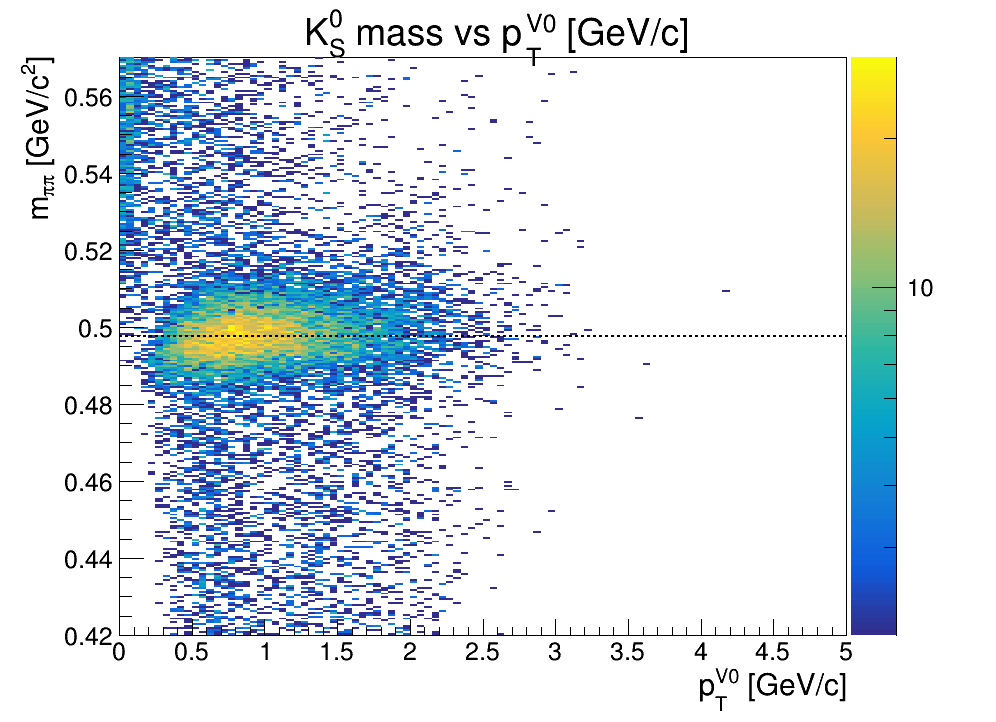

[02/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_phi


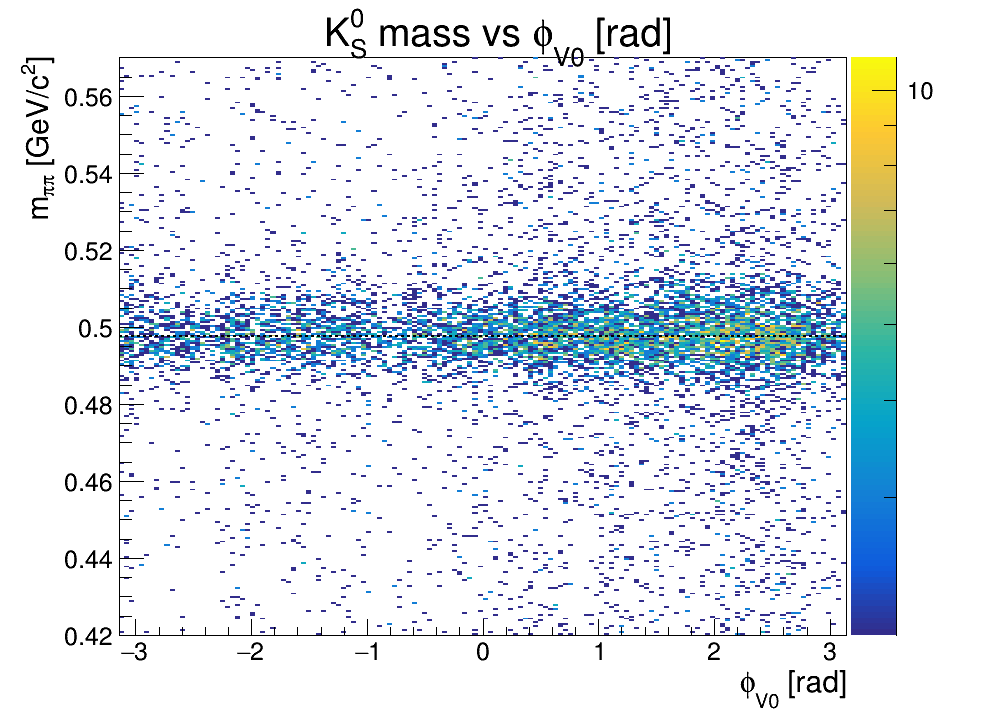

[03/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_eta


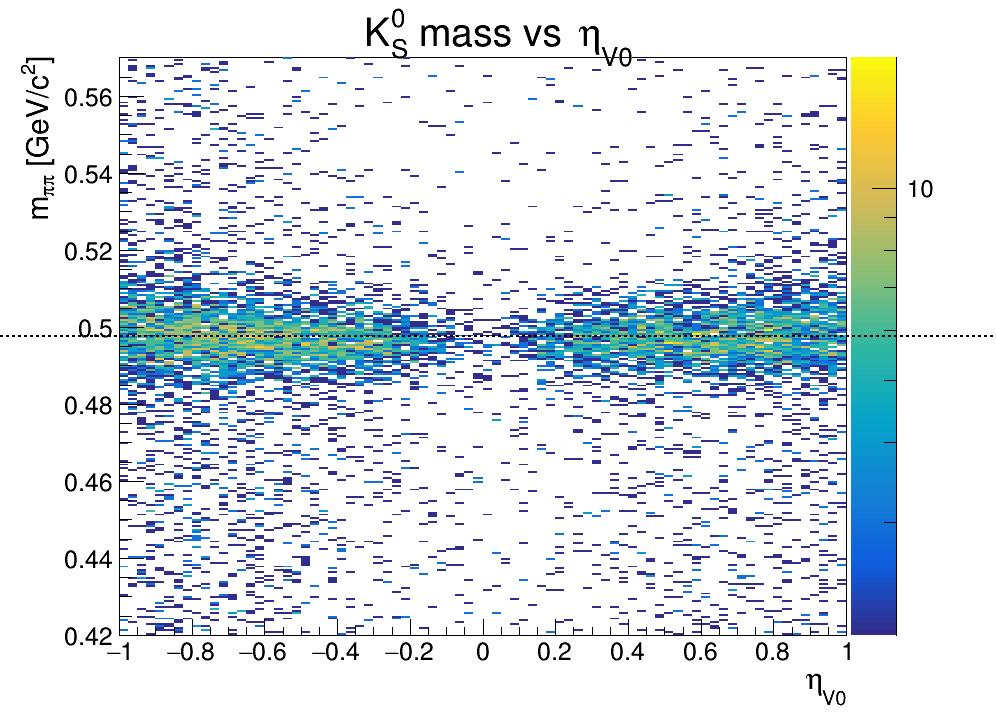

[04/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_decay_radius


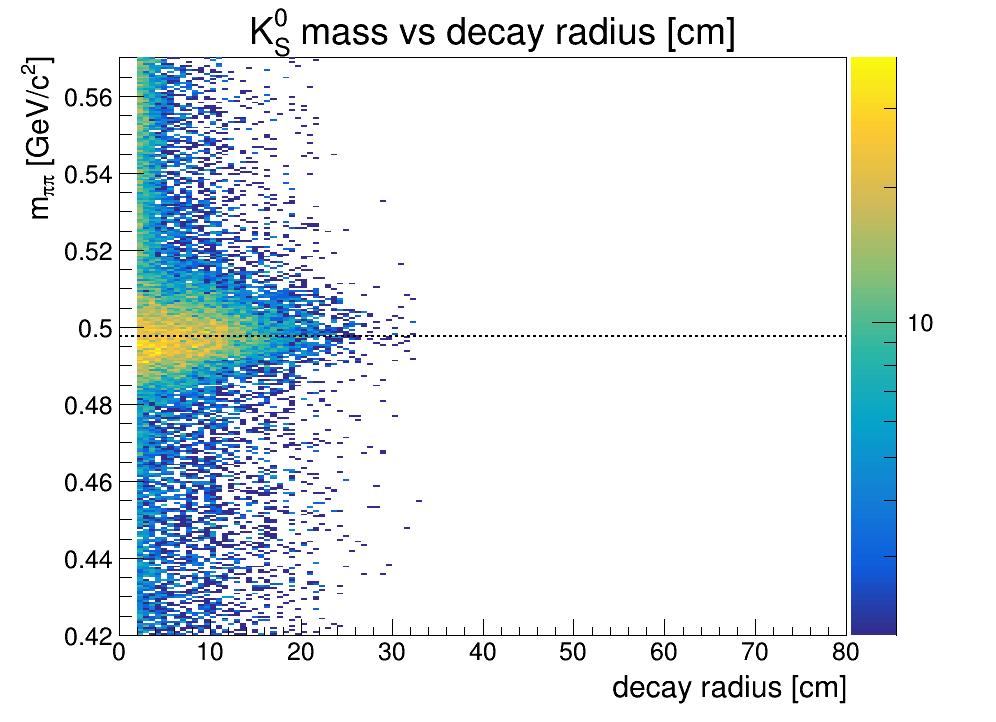

[05/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_decay_phi


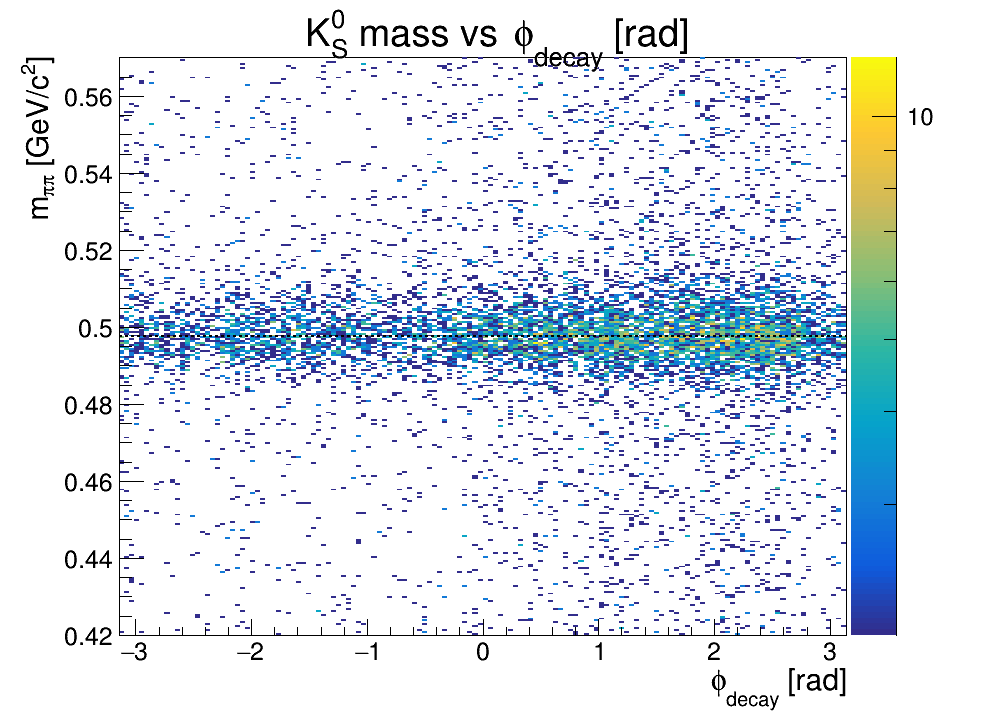

[06/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pca_z


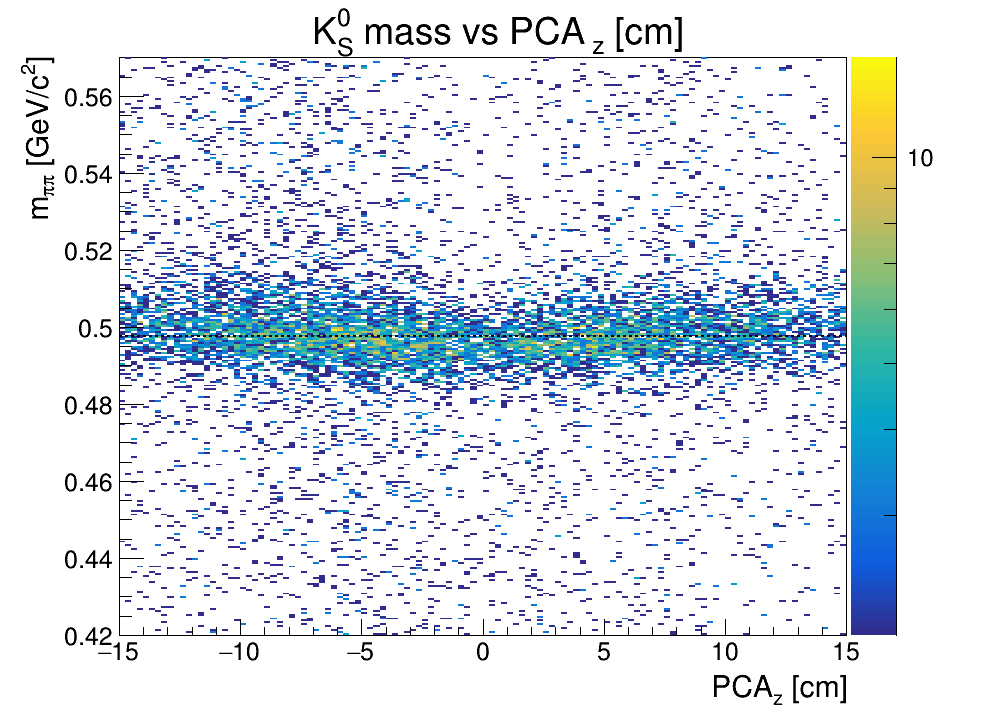

[07/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_abs_delta_pca_z


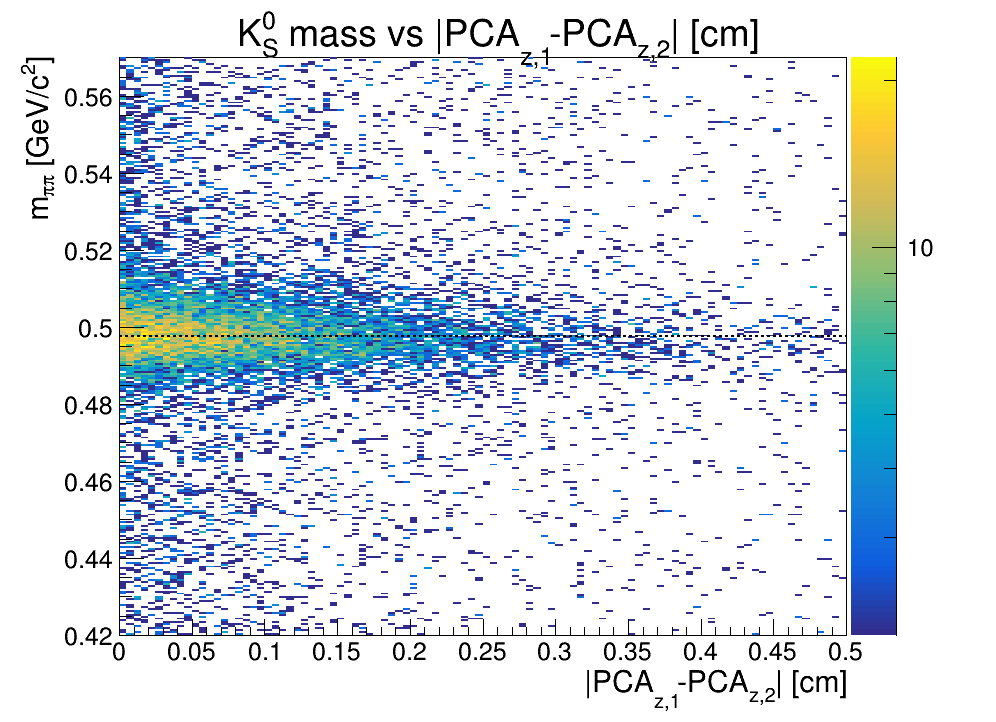

[08/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_abs_pairDCA


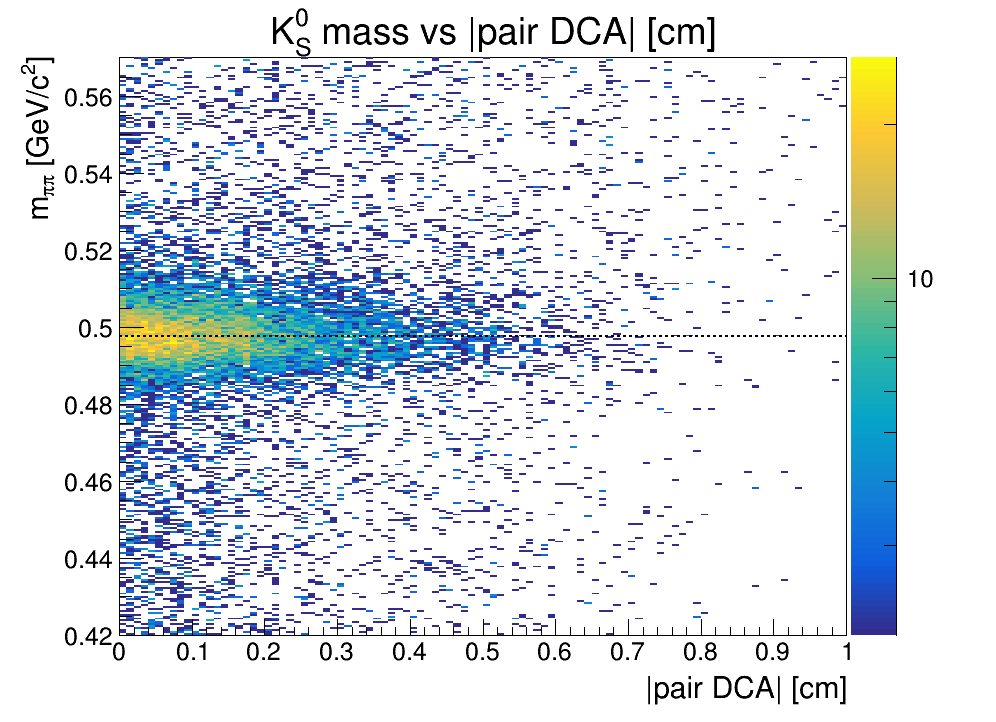

[09/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_DIRA


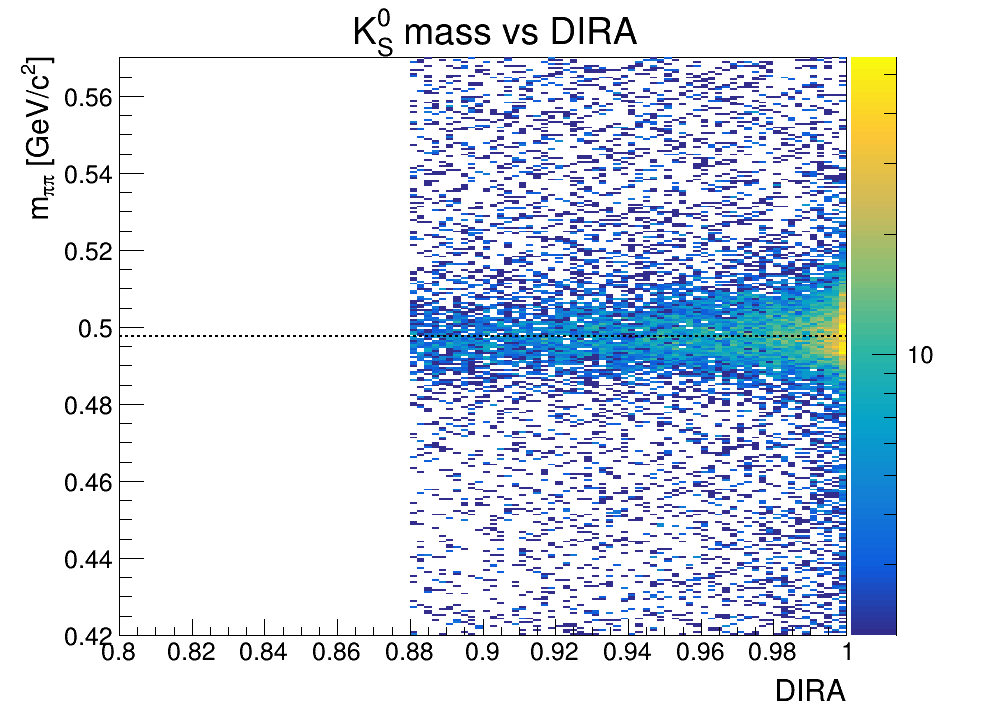

[10/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_alpha


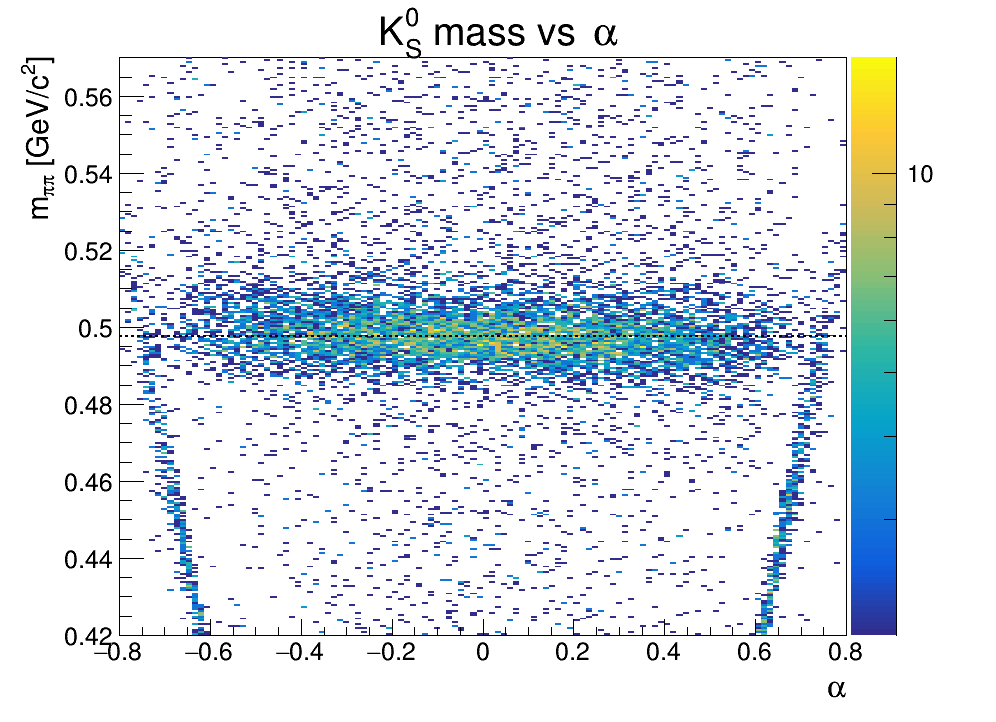

[11/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_abs_alpha


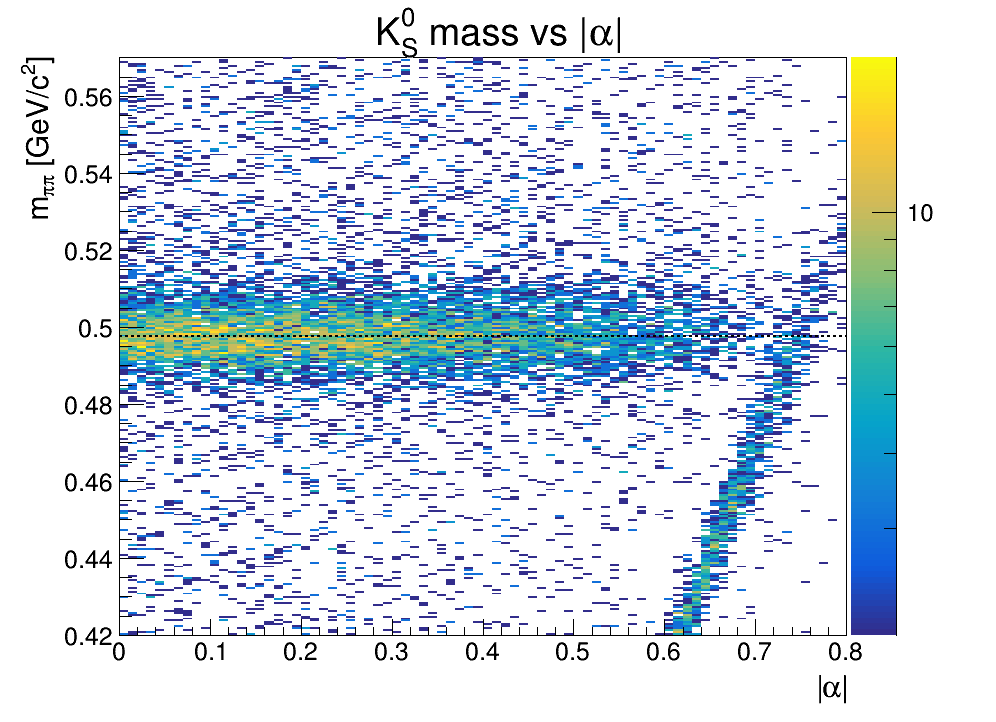

[12/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pt_positive


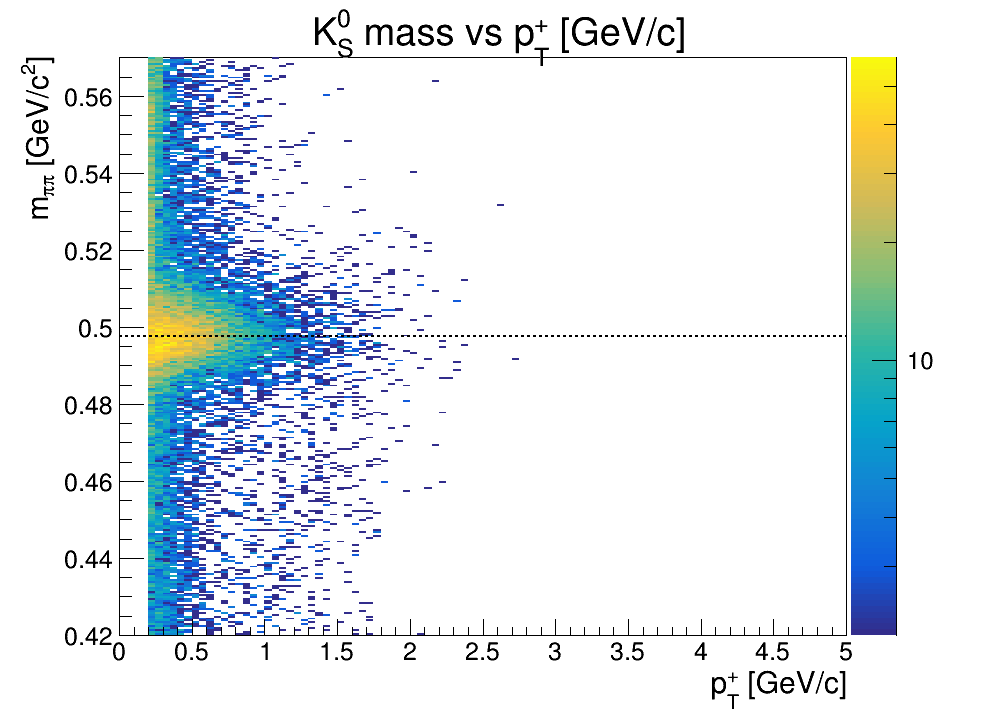

[13/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pt_negative


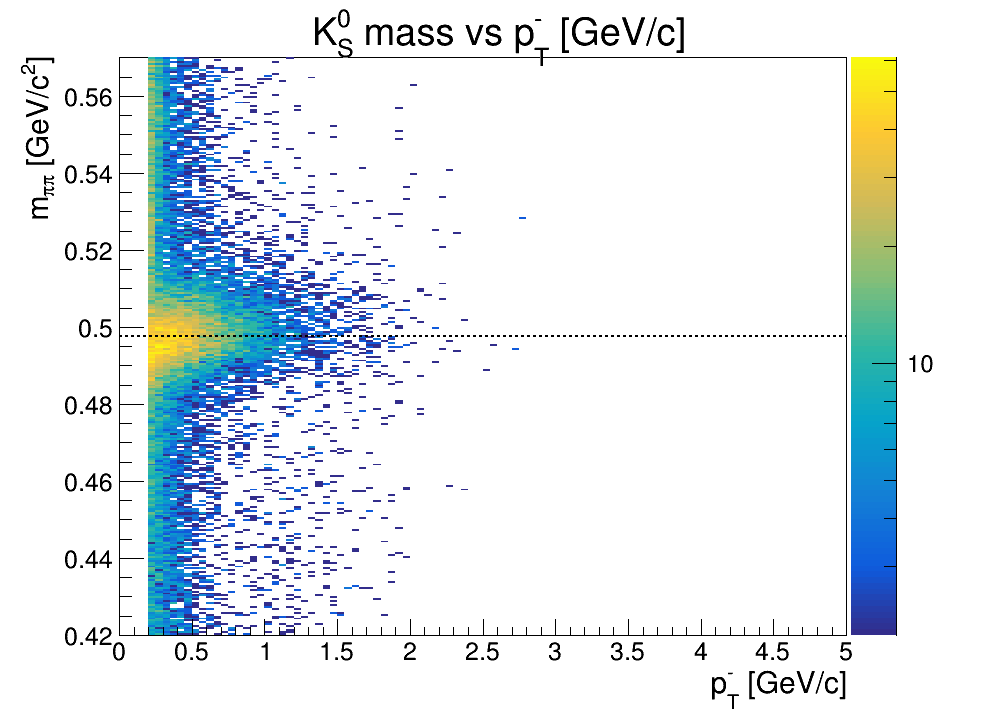

[14/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pt_min


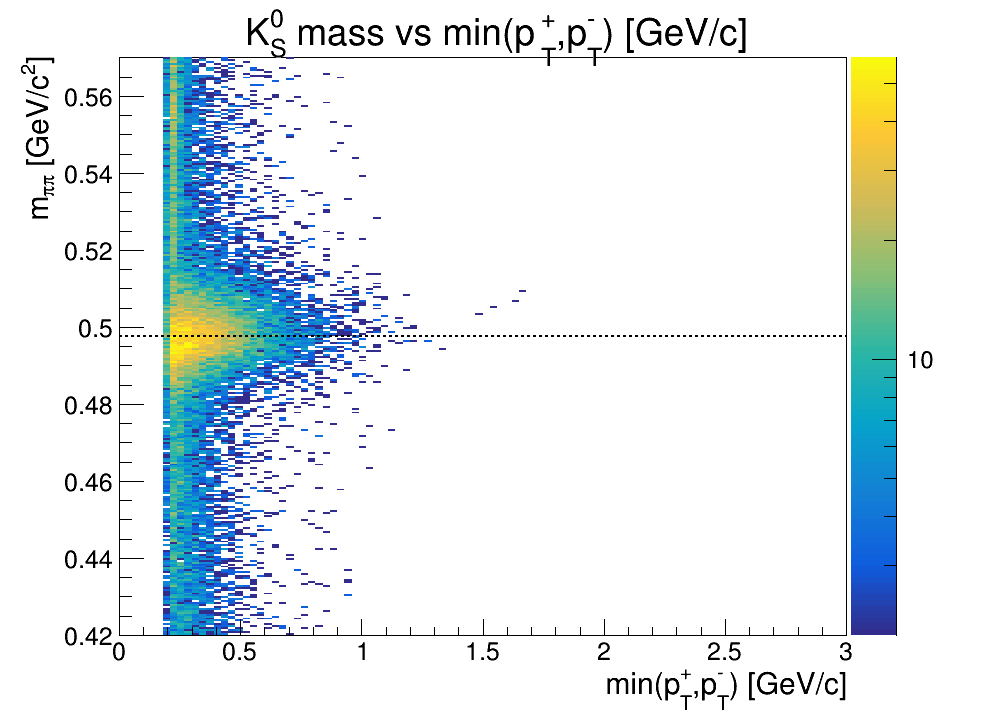

[15/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pt_max


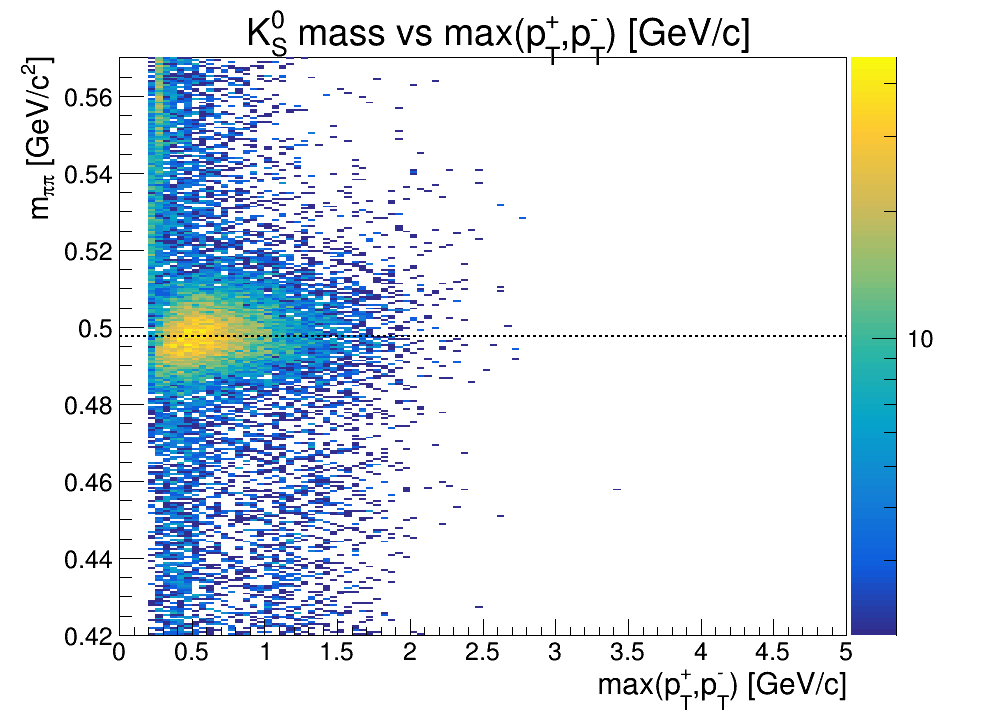

[16/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pt_asymmetry


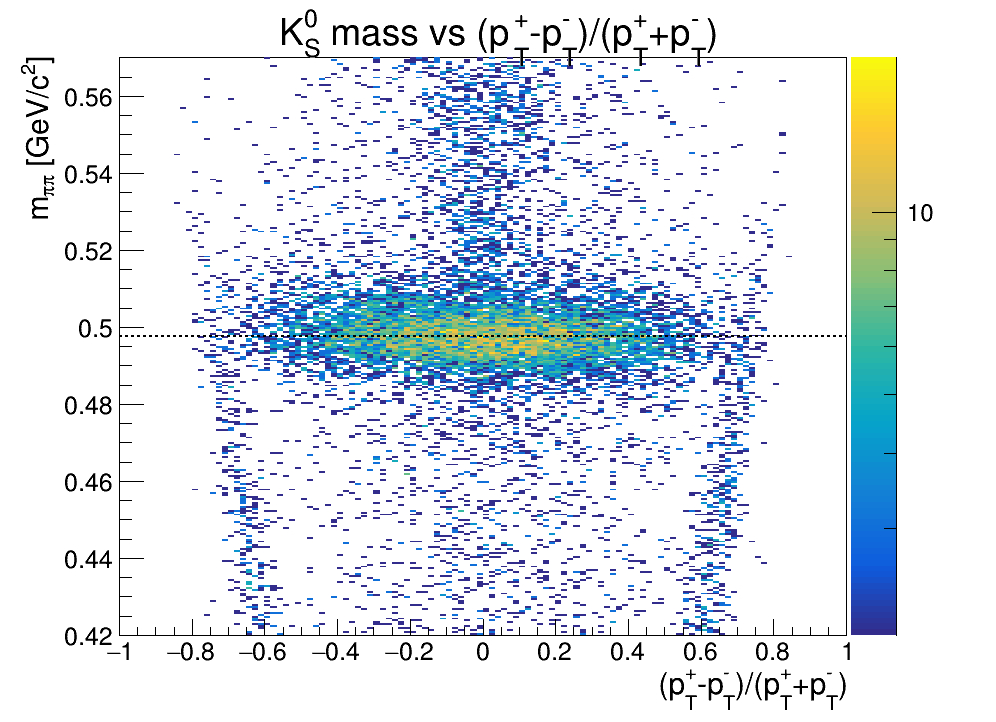

[17/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_eta_positive


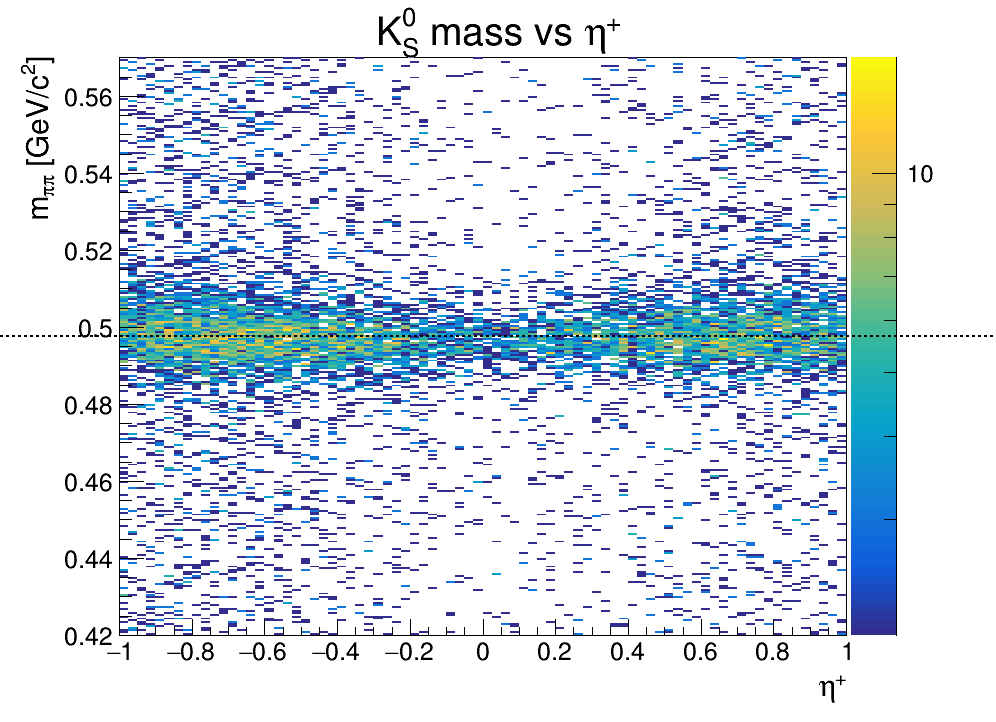

[18/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_eta_negative


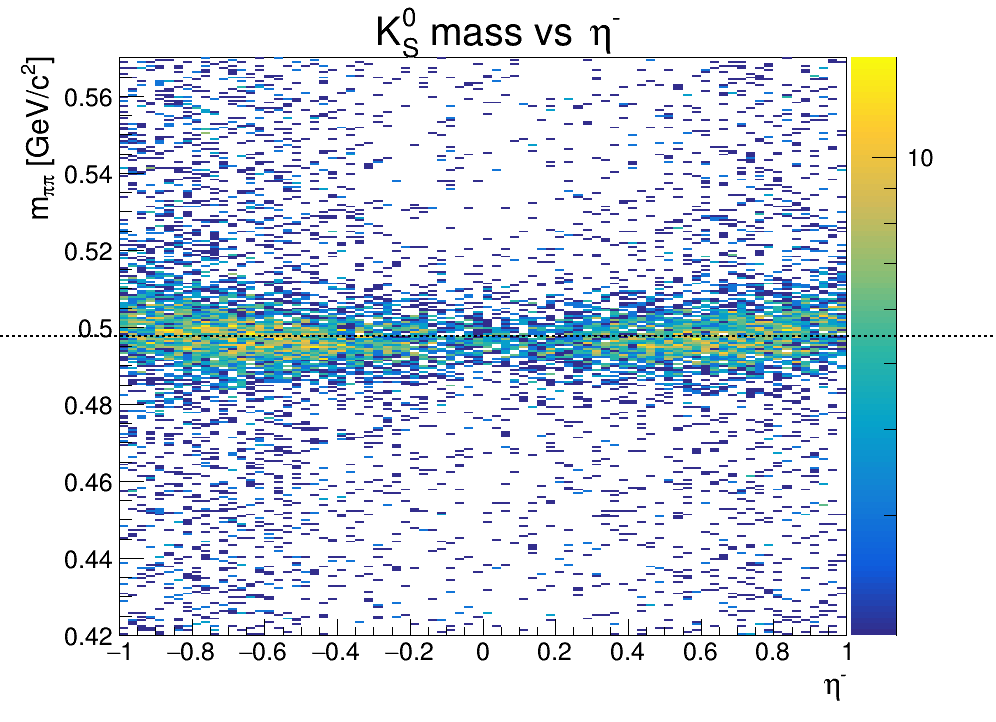

[19/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_eta_min


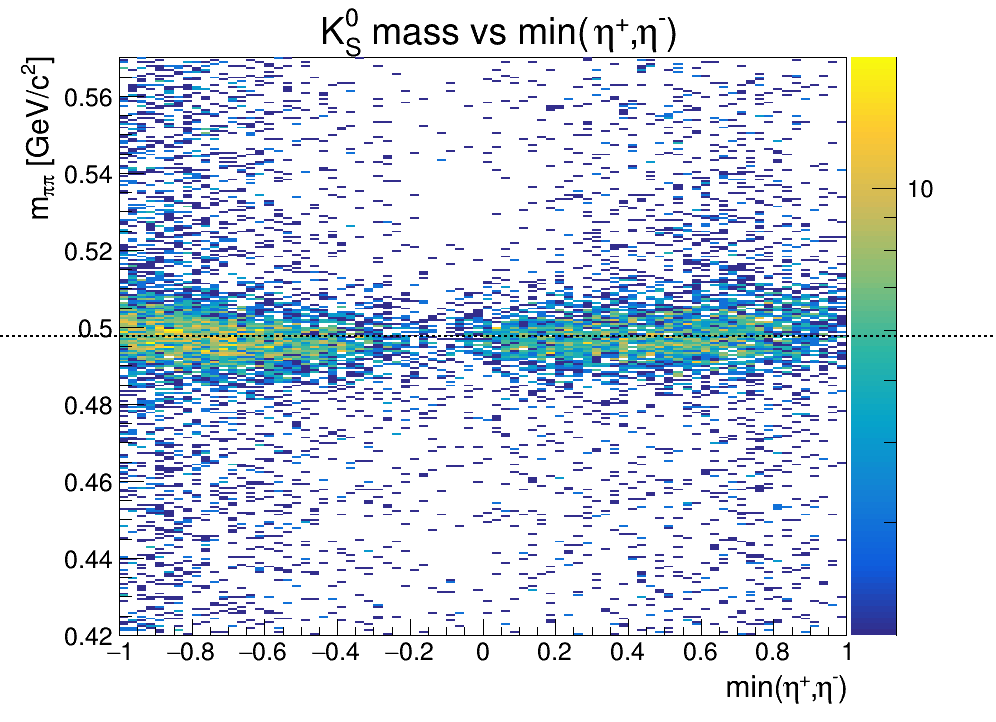

[20/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_eta_max


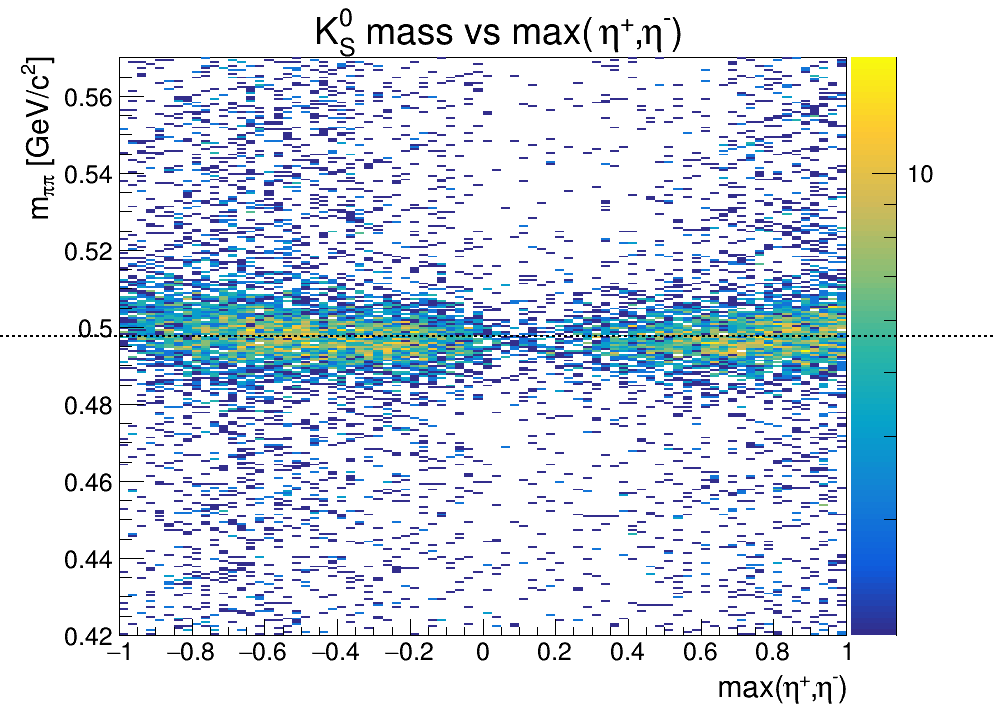

[21/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_phi_positive


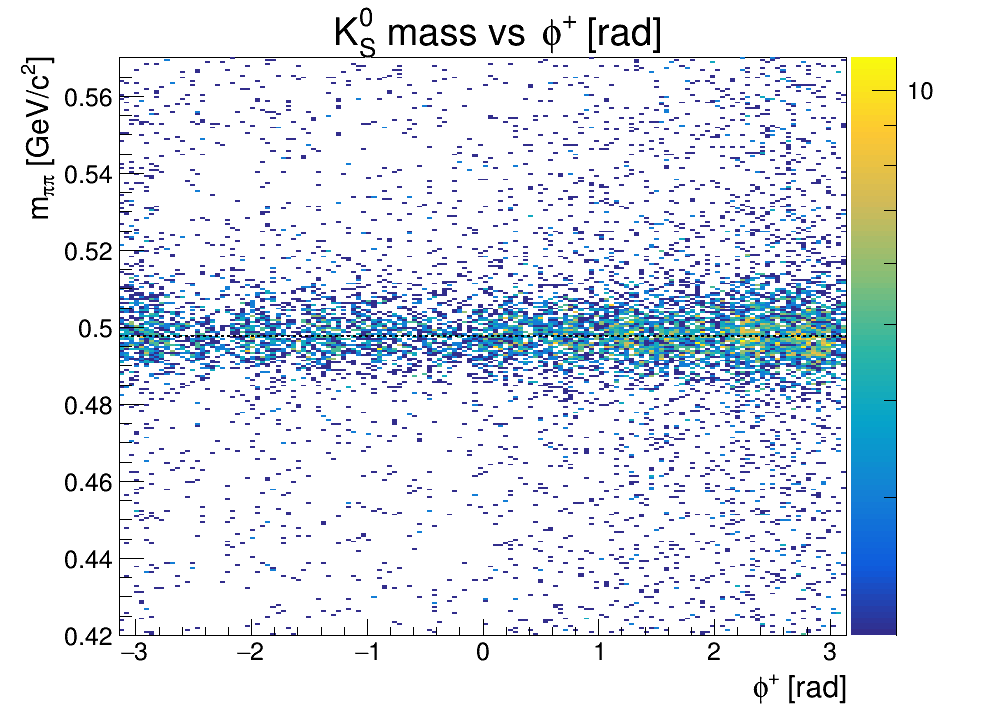

[22/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_phi_negative


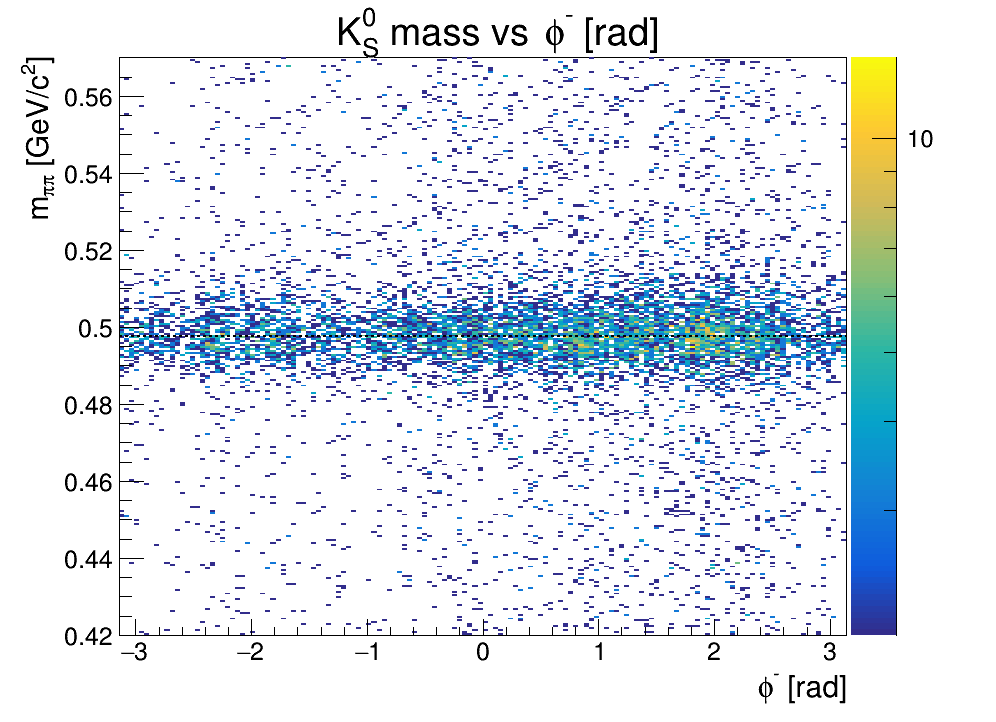

[23/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_delta_phi


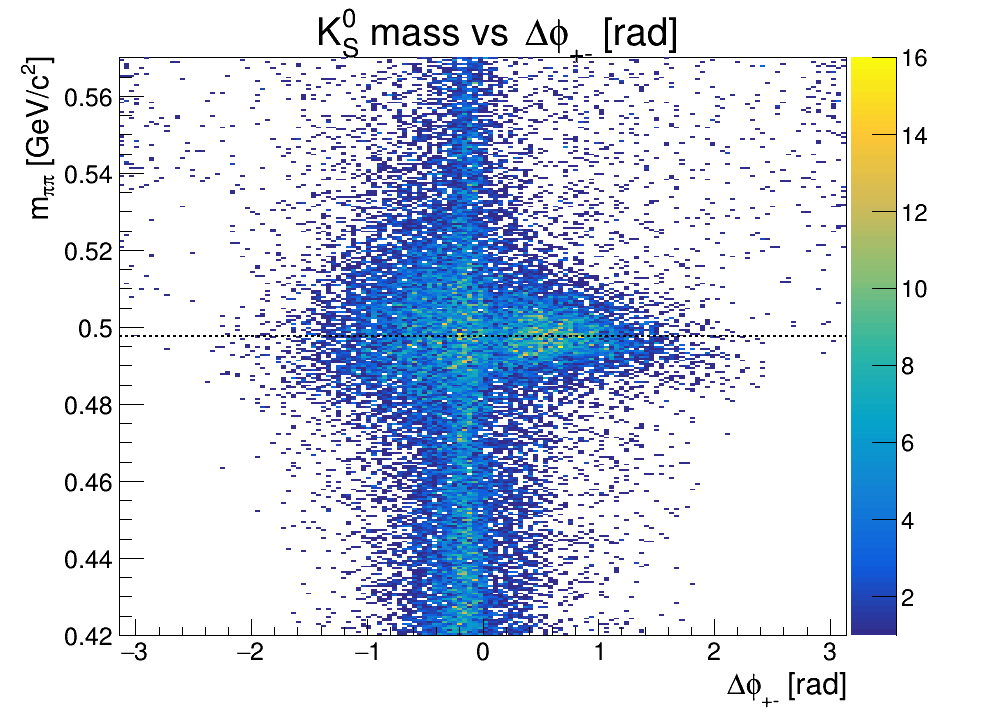

[24/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_opening_angle


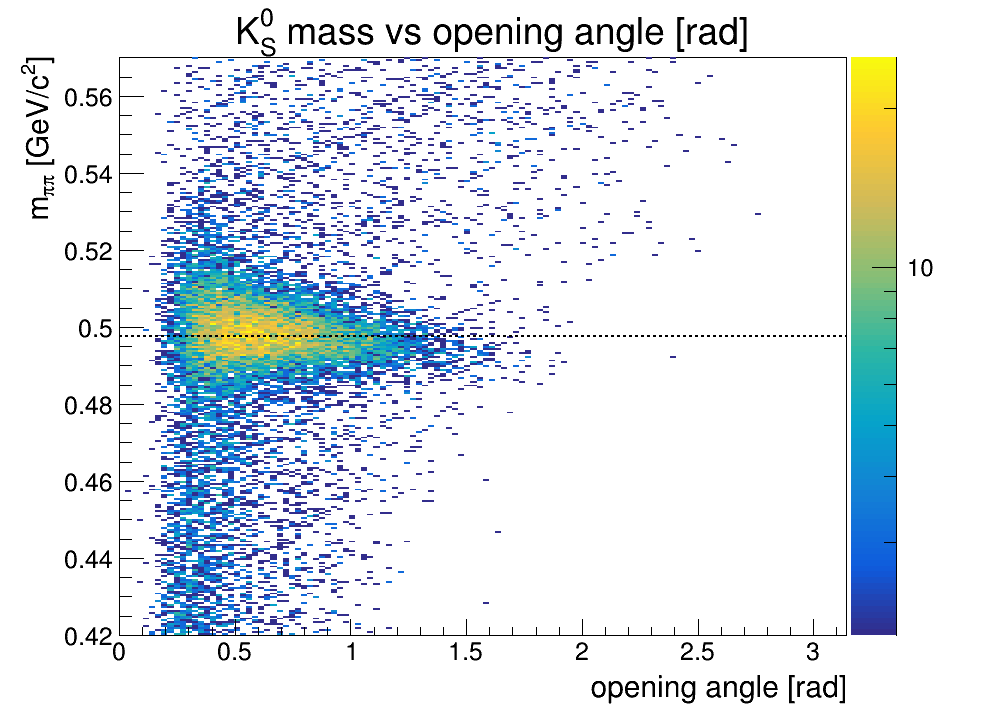

[25/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_qOverPt_positive


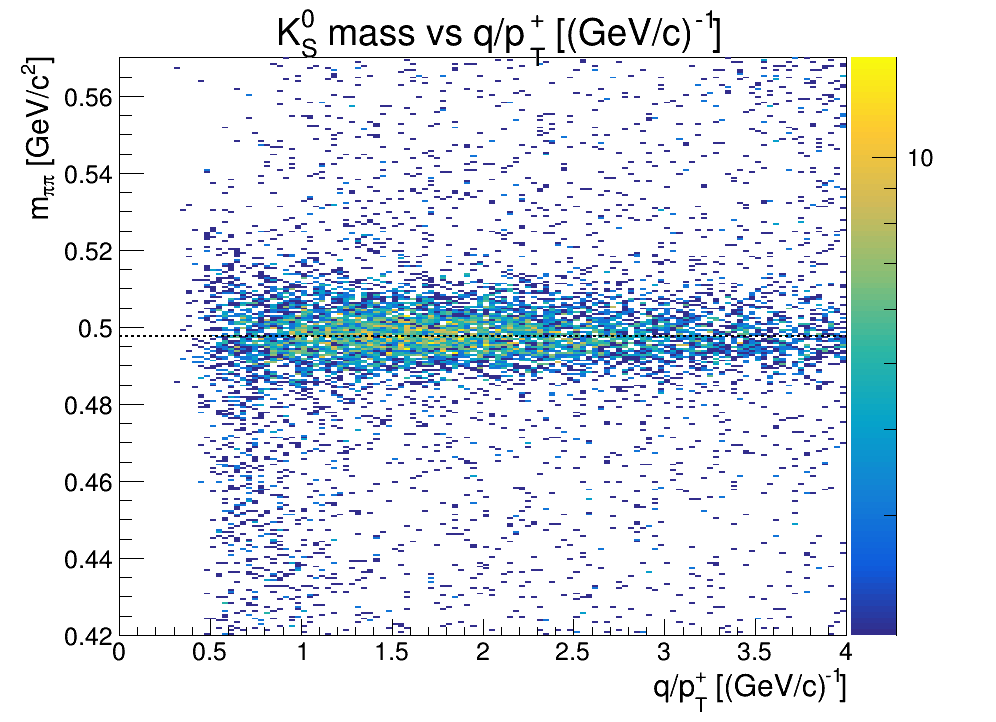

[26/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_qOverPt_negative


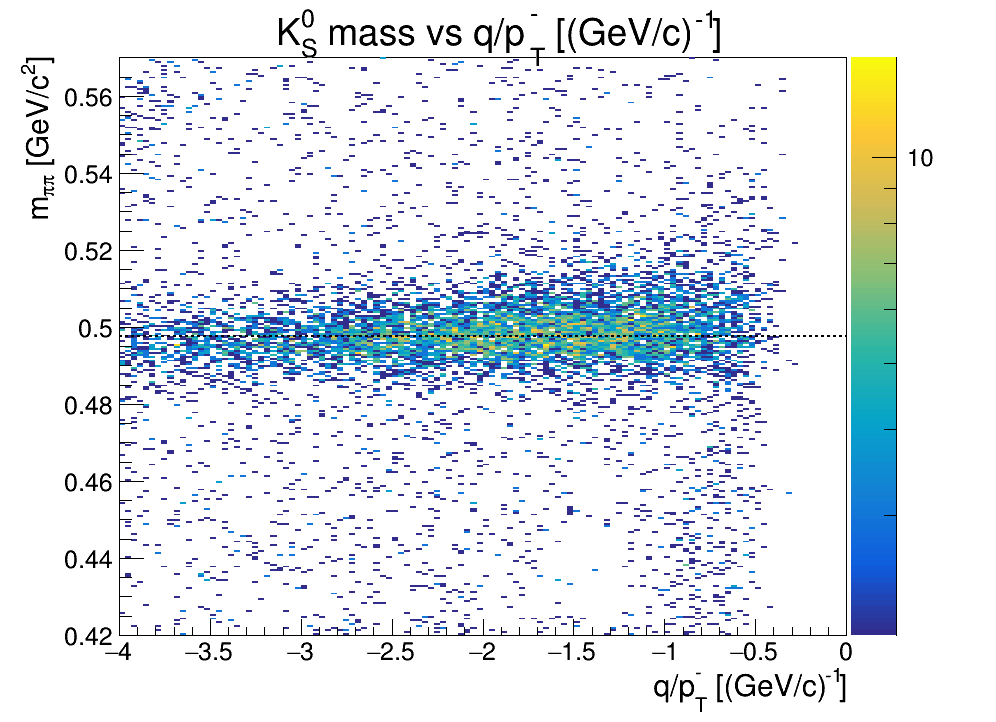

[27/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pz_positive


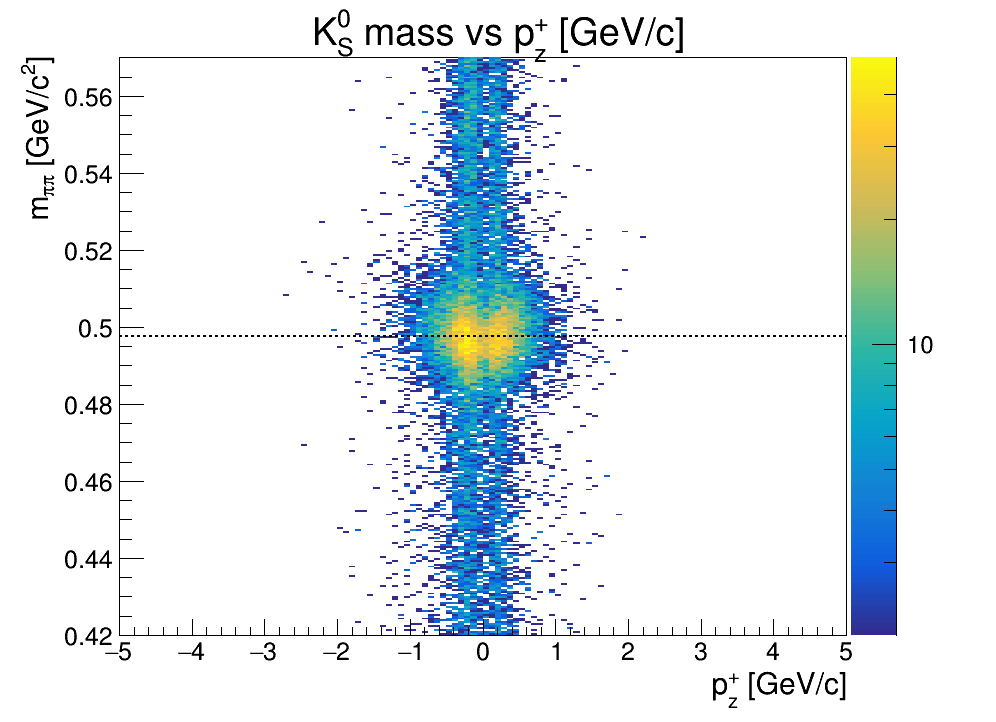

[28/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pz_negative


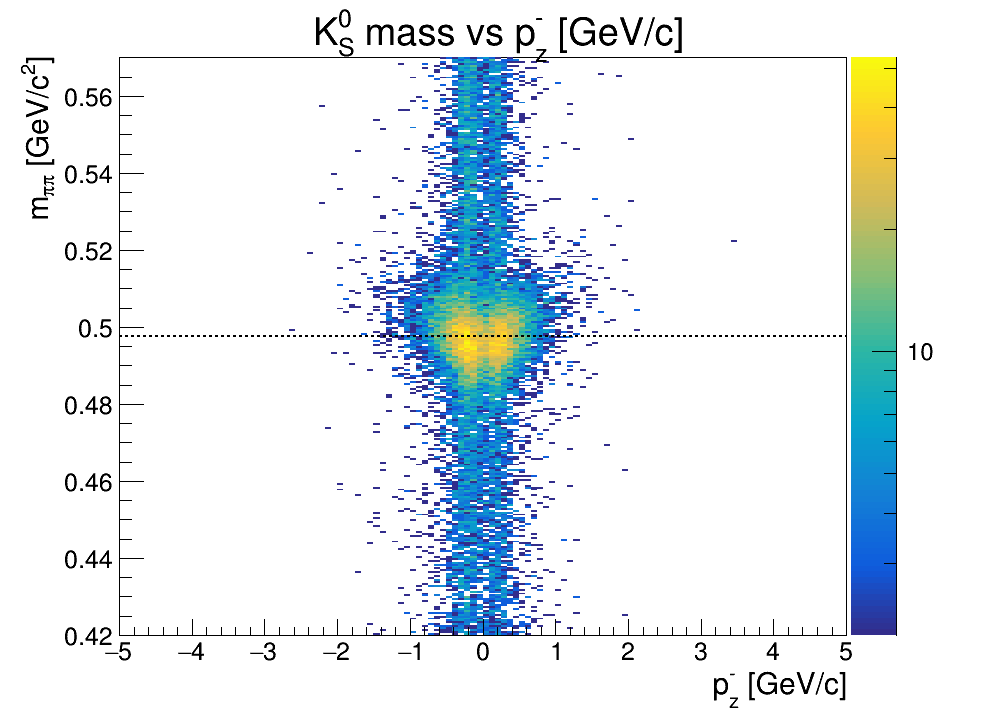

[29/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_npoints_min


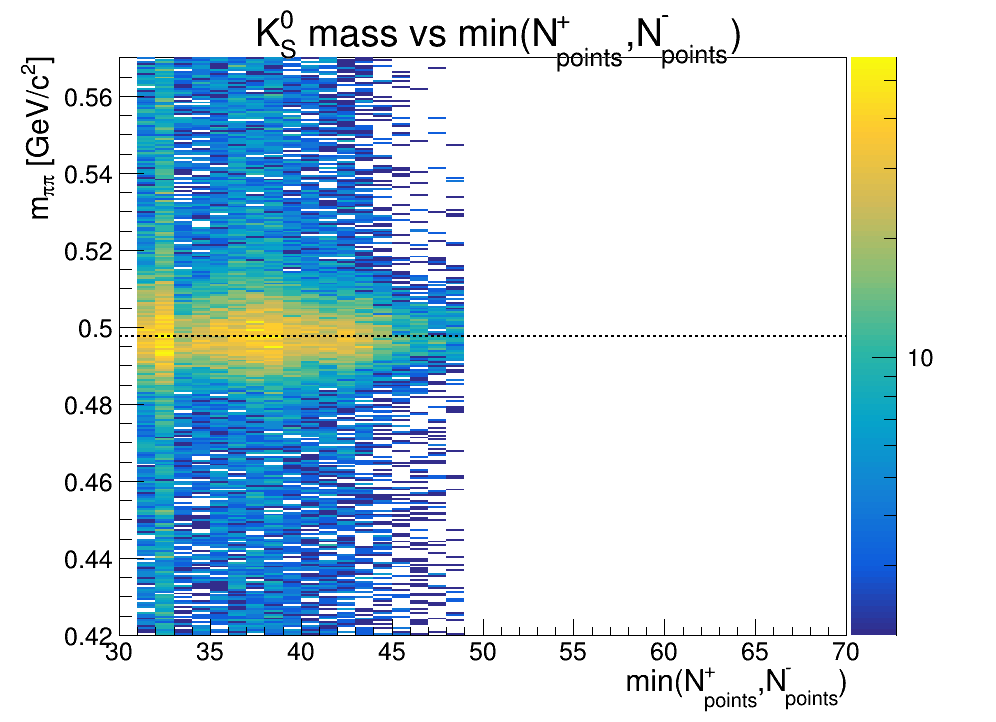

[30/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_npoints_max


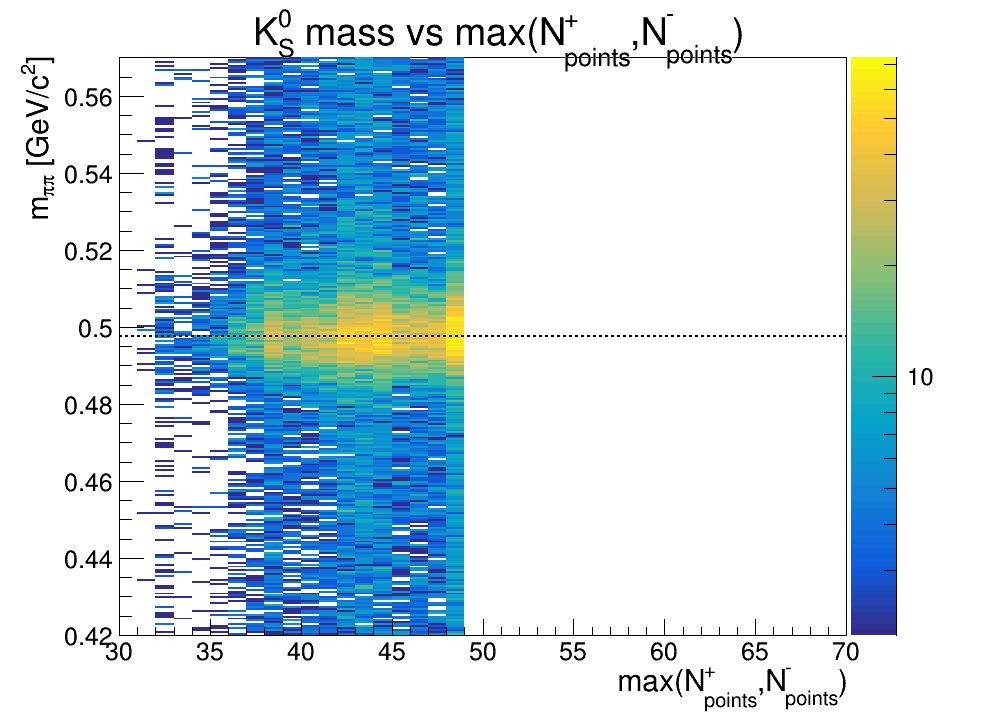

[31/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_quality_min


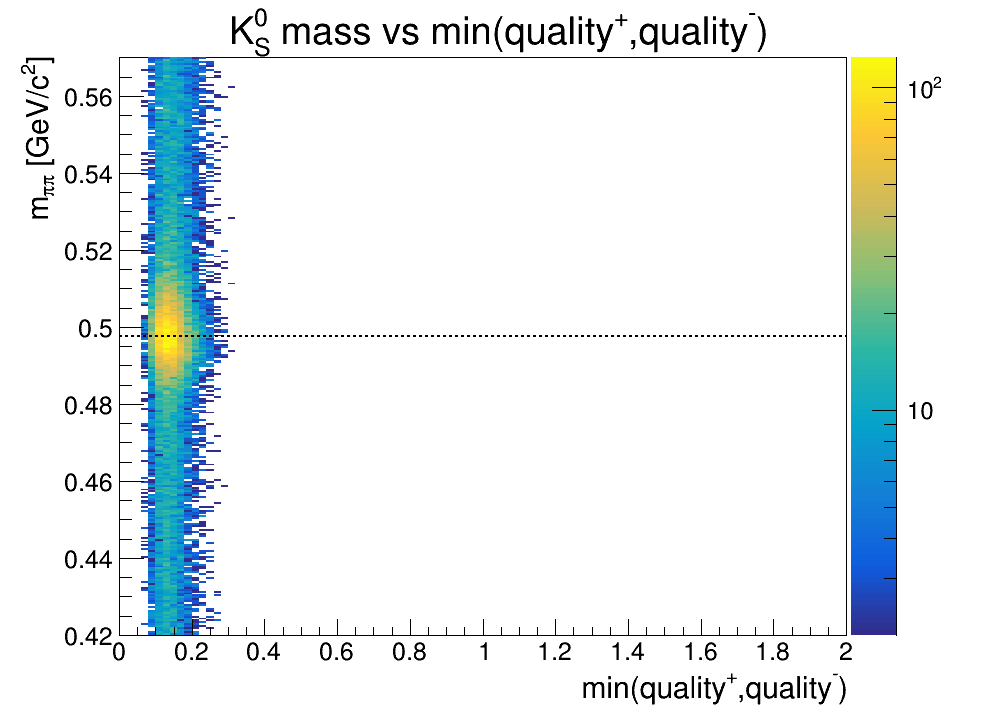

[32/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_quality_max


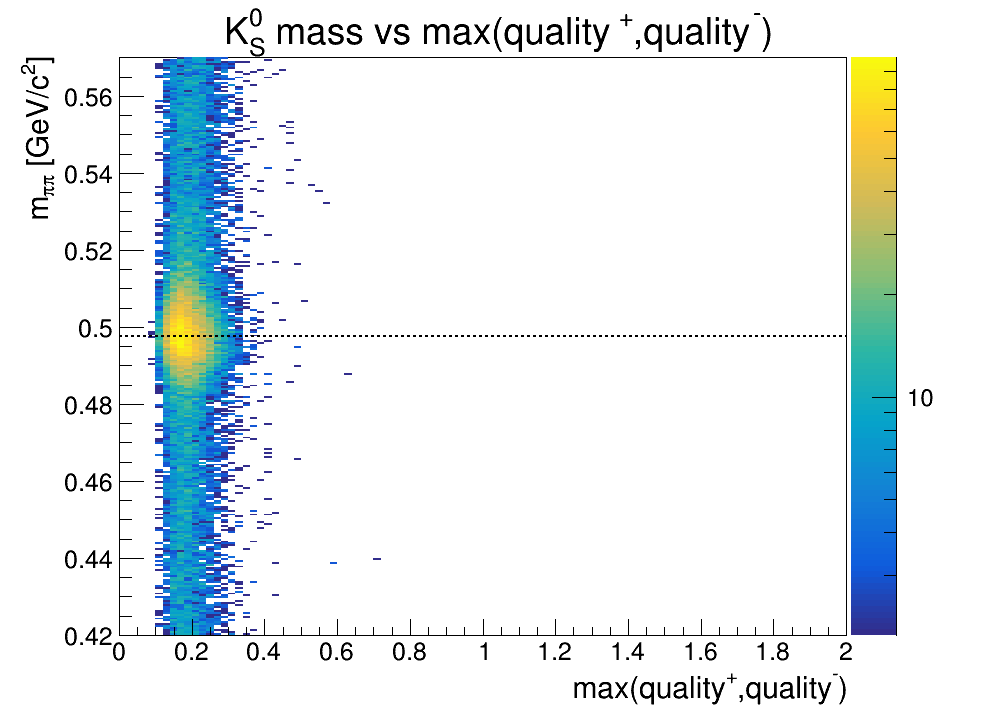

[33/37] mass_vs_phase_space_exactCut1_unlike/h_stored_mass_vs_recalculated_mass


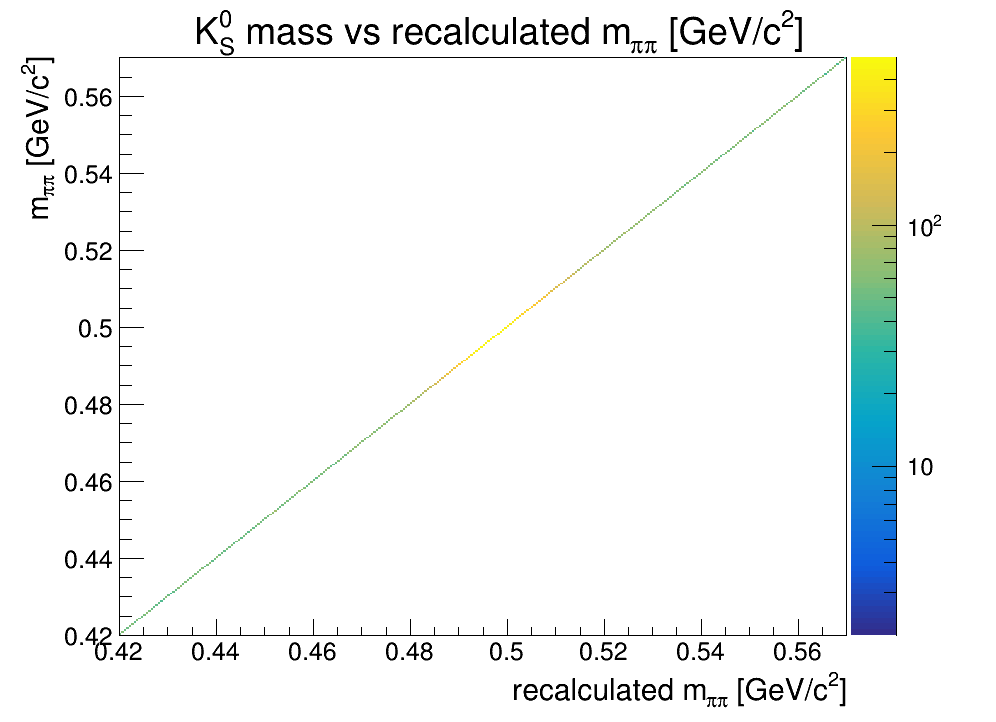

[34/37] mass_vs_phase_space_exactCut1_unlike/h_delta_phi_vs_mass_vs_pt


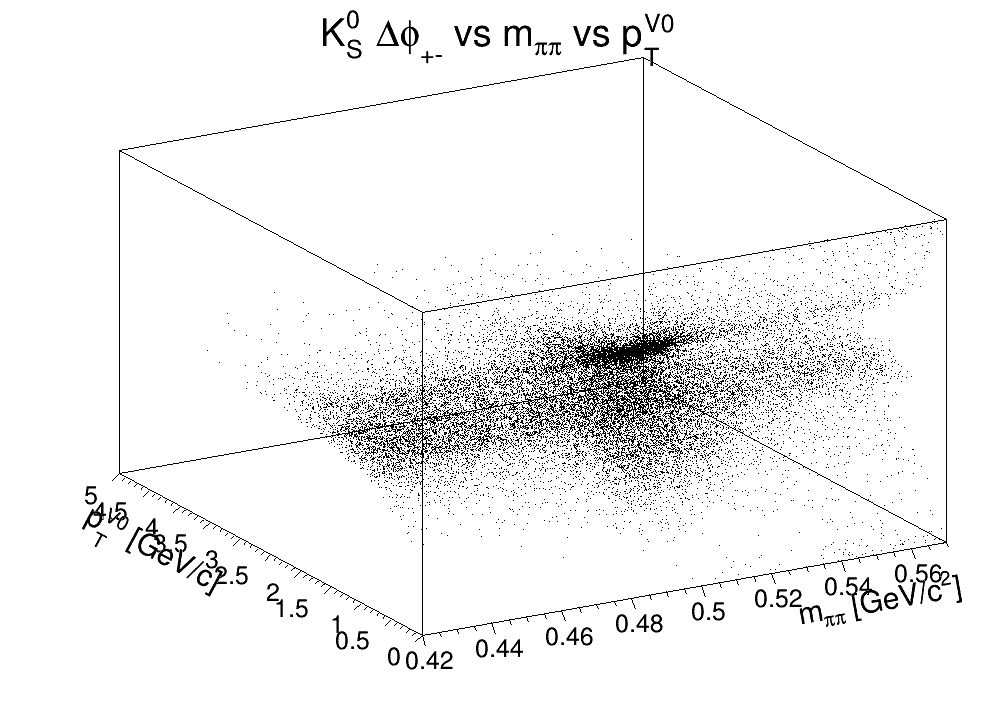

[35/37] mass_vs_phase_space_exactCut1_unlike/h_decay_radius_vs_mass_vs_pt


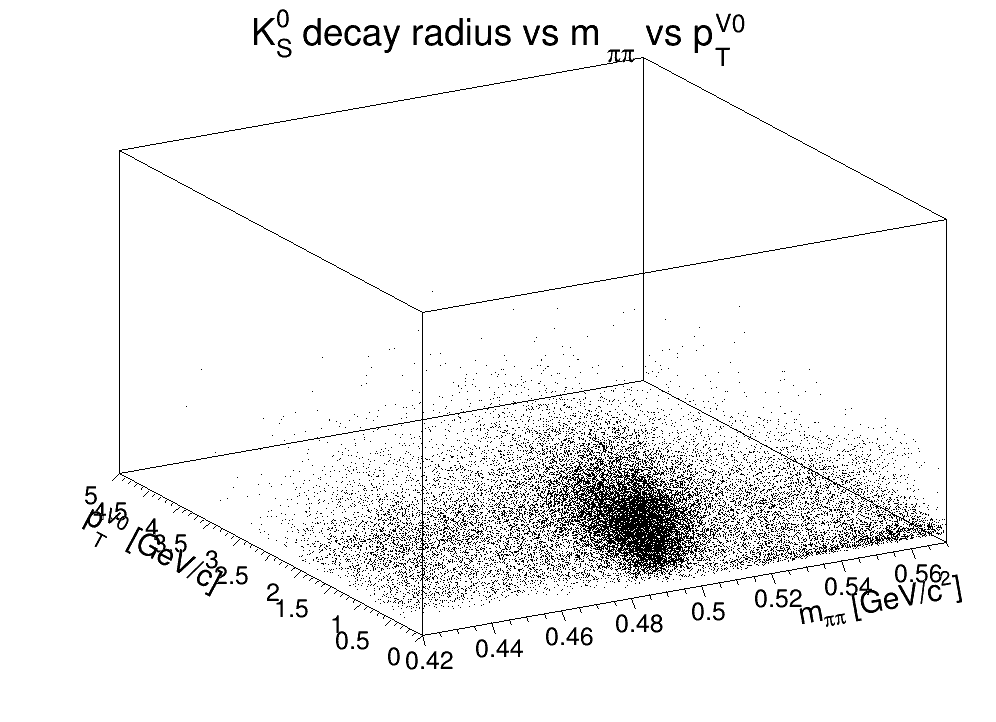

[36/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_stored_minus_recalculated


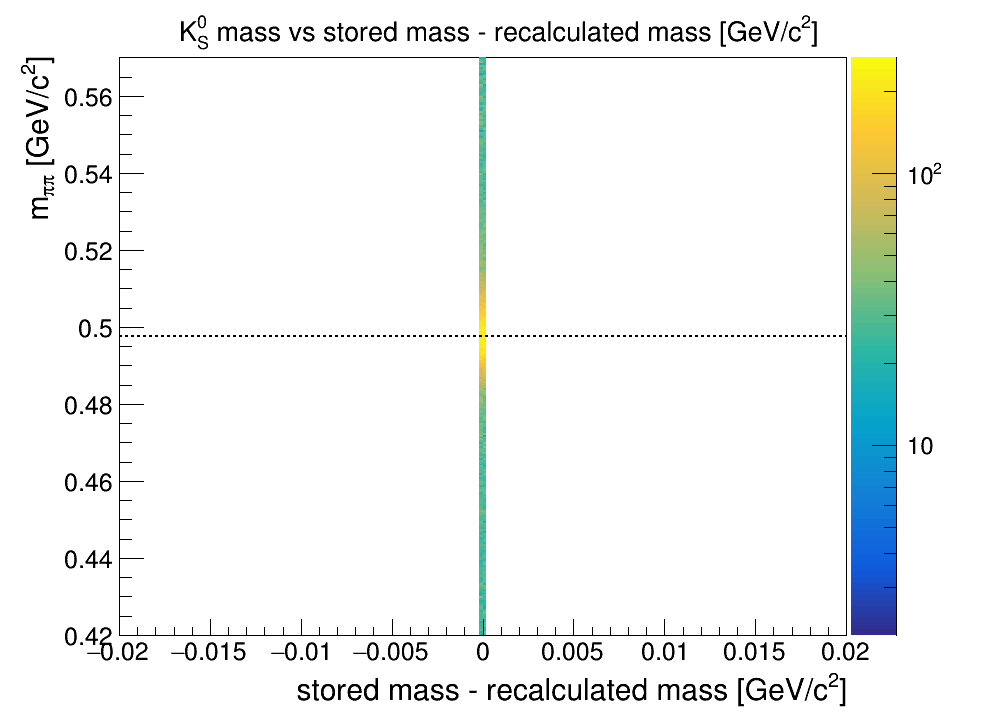

[37/37] mass_vs_phase_space_exactCut1_unlike/h_mass_vs_pt_minus_over_pt_plus


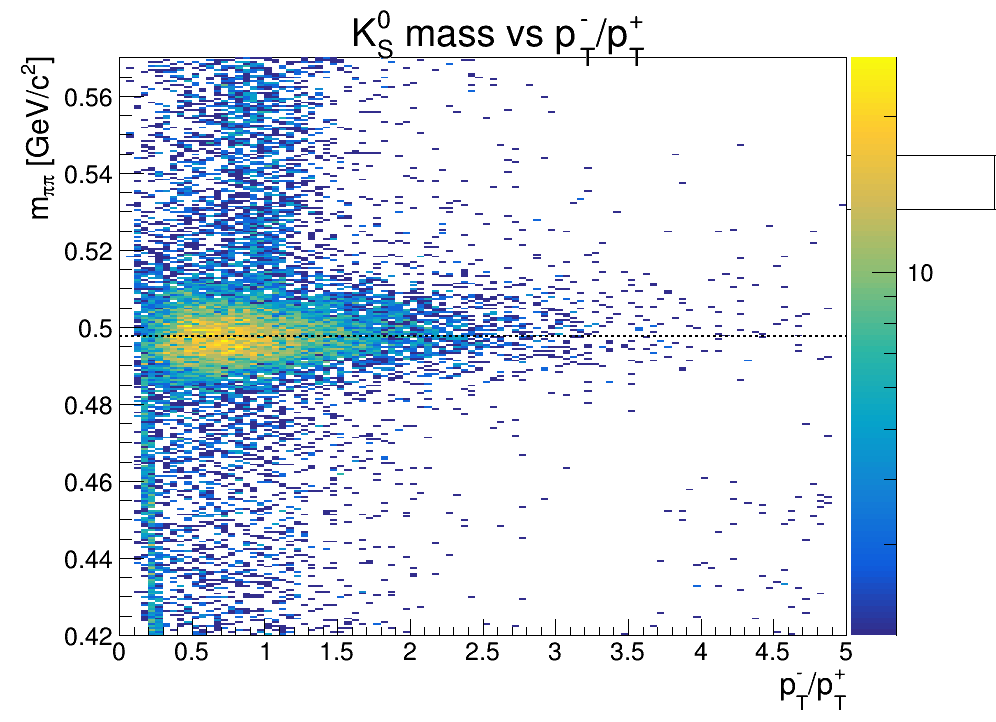

Wrote multipage PDF: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/drawings/output/k0s_double_peak_plots/k0s_double_peak_all_QA.pdf
Finished.


Info in <TCanvas::Print>: pdf file output/k0s_double_peak_plots/k0s_double_peak_all_QA.pdf has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_current_plot.png has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/k0s_double_peak_plots/k0s_double_peak_all_QA.pdf
Warning in <TPDF::TPDF::NewObject>: An Object is already open.
Info in <TCanvas::Print>: pdf file output/k0s_double_peak_plots/mass_vs_phase_space_exactCut1_unlike__h_mass_vs_v0_pt.pdf has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_current_plot.png has been created
Warning in <TPDF::TPDF::EndObject>: No Object currently opened.
Info in <TCanvas::Print>: Current canvas added to pdf file output/k0s_double_peak_plots/k0s_double_peak_all_QA.pdf
Warning in <TPDF::TPDF::NewObject>: An Object is already open.
Info in <TCanvas::Print>: pdf file output/k0s_double_peak_plots/mass_vs_phase_space_exactCut1_unlike__h_mass_vs_v0_phi.pdf has been cre

In [6]:
# Draw everything, display inline, and optionally save.

canvas = ROOT.TCanvas("c_k0s_qa", "K0S QA", CANVAS_WIDTH, CANVAS_HEIGHT)

multipage_pdf = OUTPUT_DIRECTORY / MULTIPAGE_PDF_NAME
temporary_png = OUTPUT_DIRECTORY / "_current_plot.png"

if SAVE_MULTIPAGE_PDF and all_histograms:
    canvas.Print(f"{multipage_pdf}[")

for index, (full_path, hist) in enumerate(all_histograms, start=1):
    print(f"[{index:02d}/{len(all_histograms):02d}] {full_path}")

    keep_alive = draw_histogram(canvas, hist, full_path)
    base_name = sanitize_filename(full_path)

    # Display every plot in the notebook.
    show_canvas(canvas, temporary_png)

    if SAVE_MULTIPAGE_PDF:
        canvas.Print(str(multipage_pdf))

    if SAVE_INDIVIDUAL_PDF:
        canvas.SaveAs(str(OUTPUT_DIRECTORY / f"{base_name}.pdf"))

    if SAVE_PNG:
        canvas.SaveAs(str(OUTPUT_DIRECTORY / f"{base_name}.png"))

if SAVE_MULTIPAGE_PDF and all_histograms:
    canvas.Print(f"{multipage_pdf}]")
    print(f"Wrote multipage PDF: {multipage_pdf.resolve()}")

if temporary_png.exists():
    temporary_png.unlink()

print("Finished.")


## Plot only selected QA variables

Use this cell when drawing all histograms is too much for an interactive session. Edit `NAME_FILTERS` to select particular plots. The matching is performed on the full ROOT path.


Selected 8 histograms
mass_vs_phase_space_exactCut1_unlike/h_mass_vs_v0_phi


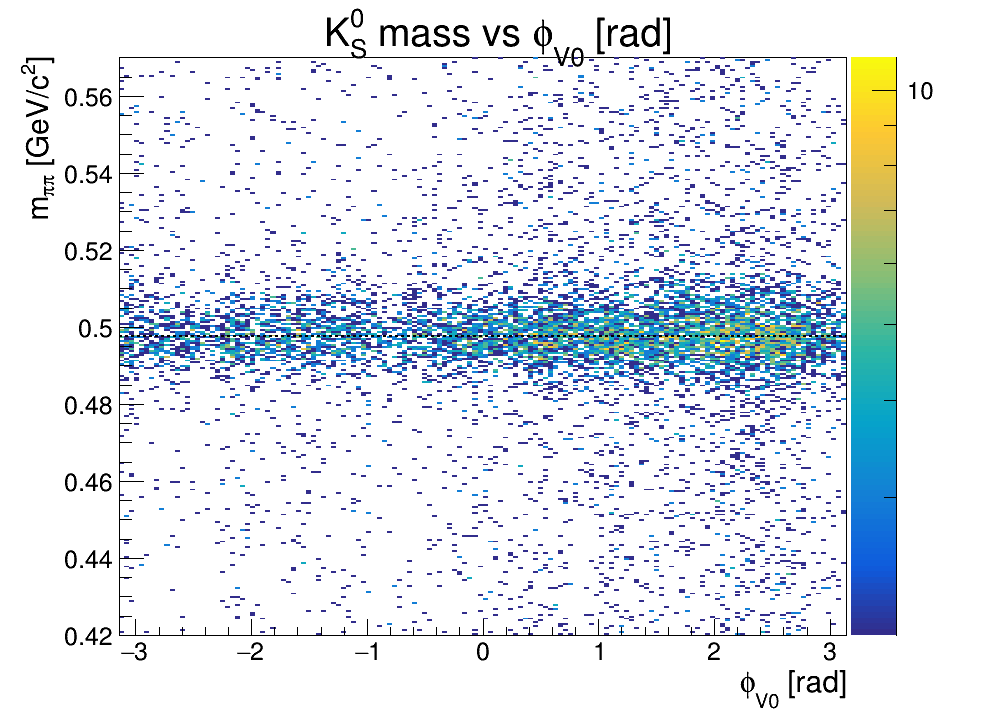

mass_vs_phase_space_exactCut1_unlike/h_mass_vs_decay_phi


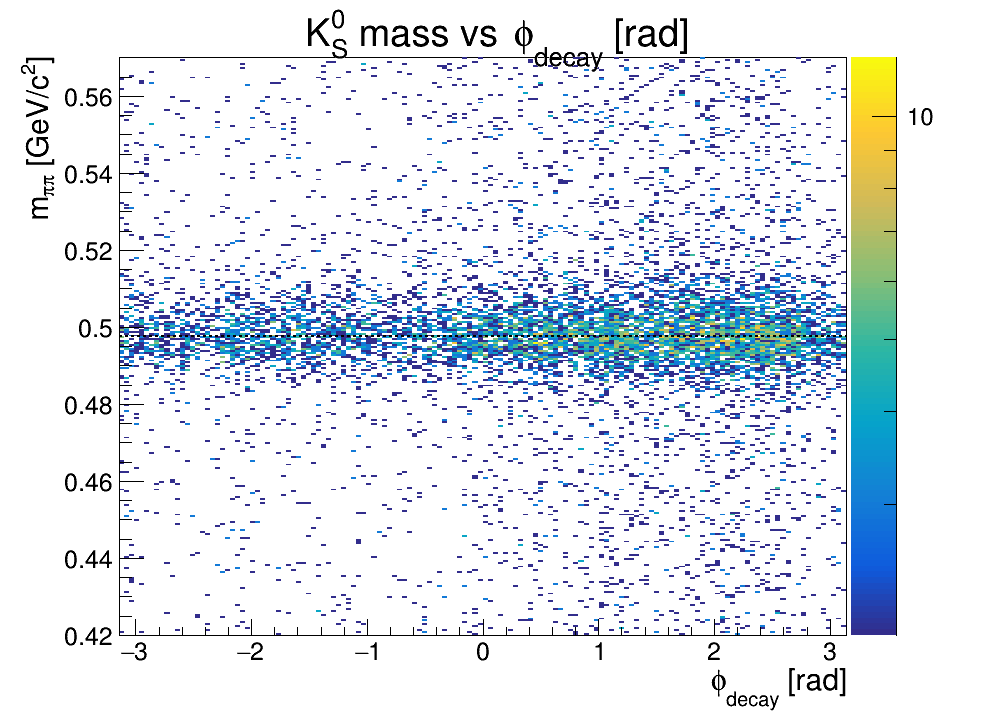

mass_vs_phase_space_exactCut1_unlike/h_mass_vs_phi_positive


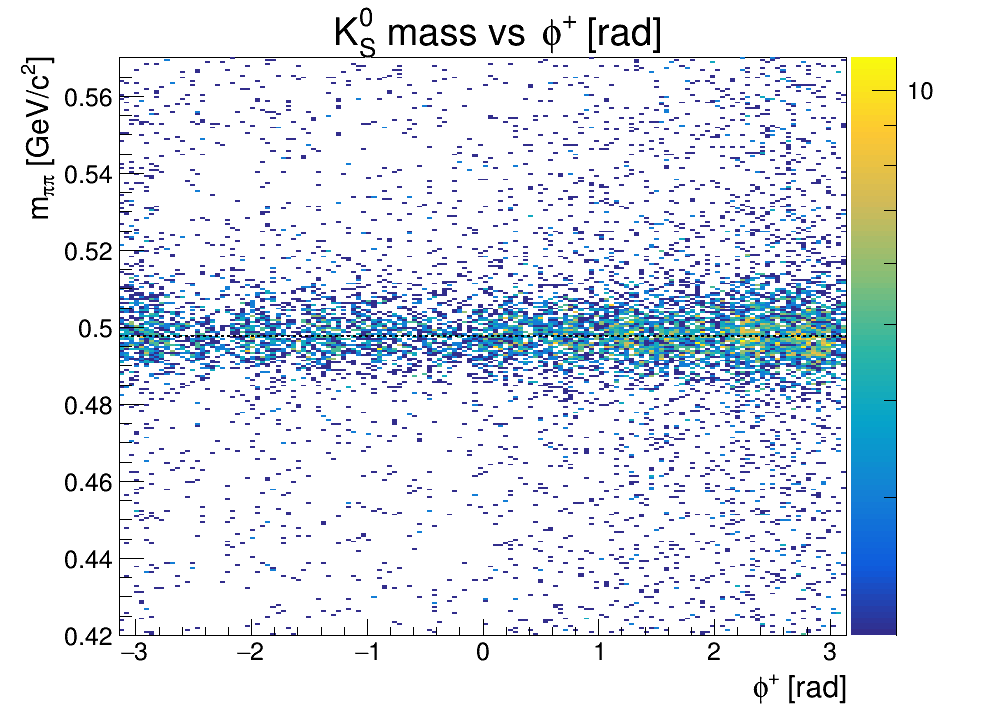

mass_vs_phase_space_exactCut1_unlike/h_mass_vs_phi_negative


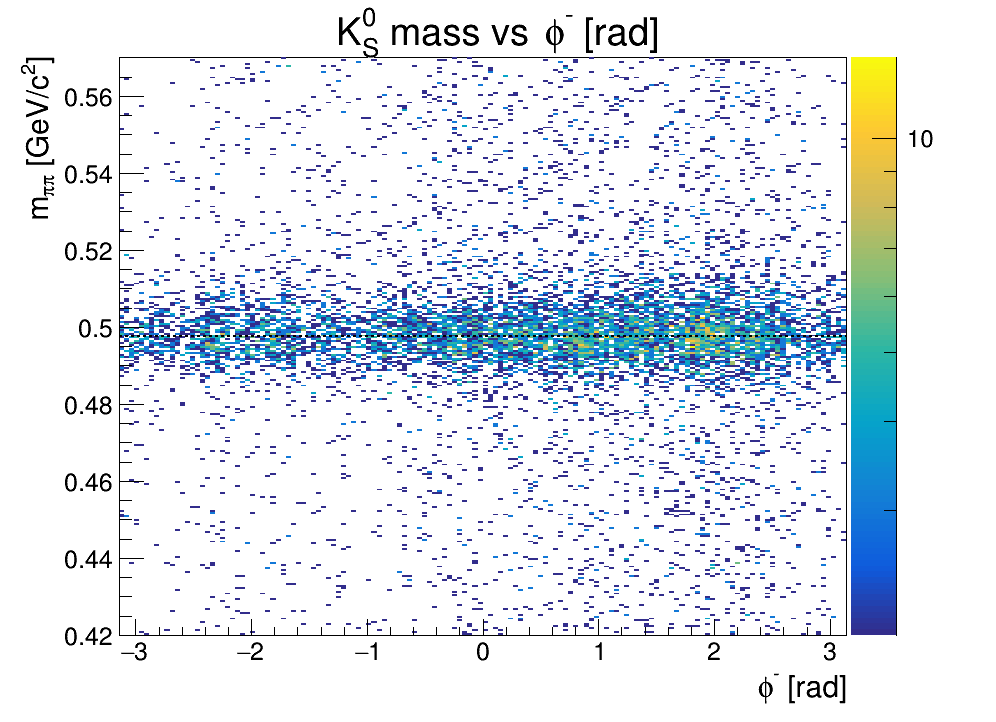

mass_vs_phase_space_exactCut1_unlike/h_mass_vs_delta_phi


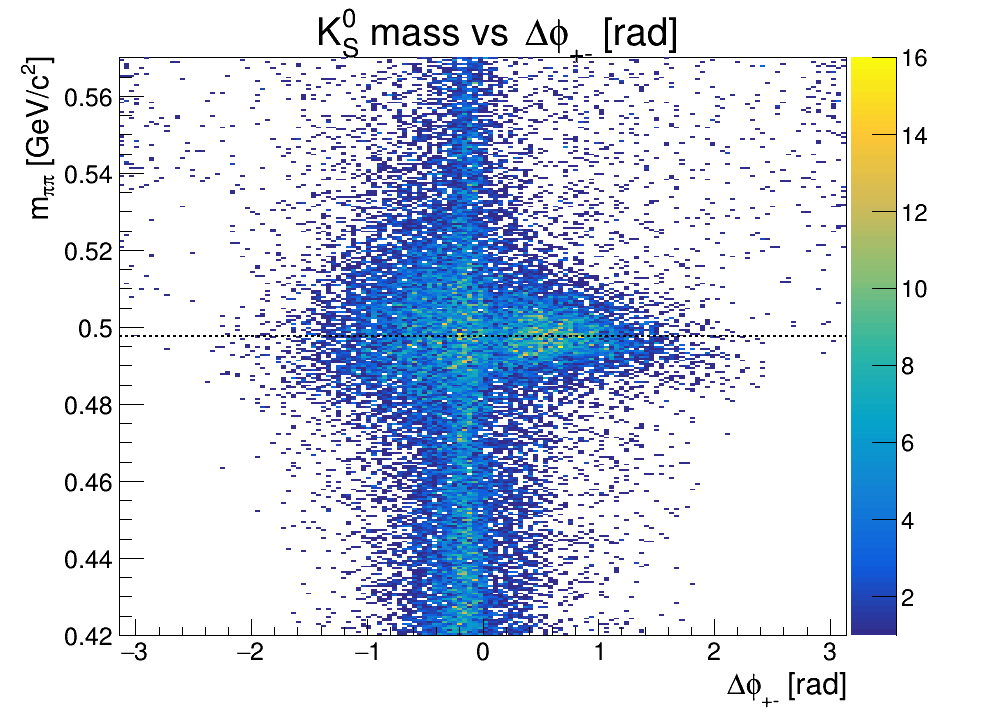

mass_vs_phase_space_exactCut1_unlike/h_mass_vs_qOverPt_positive


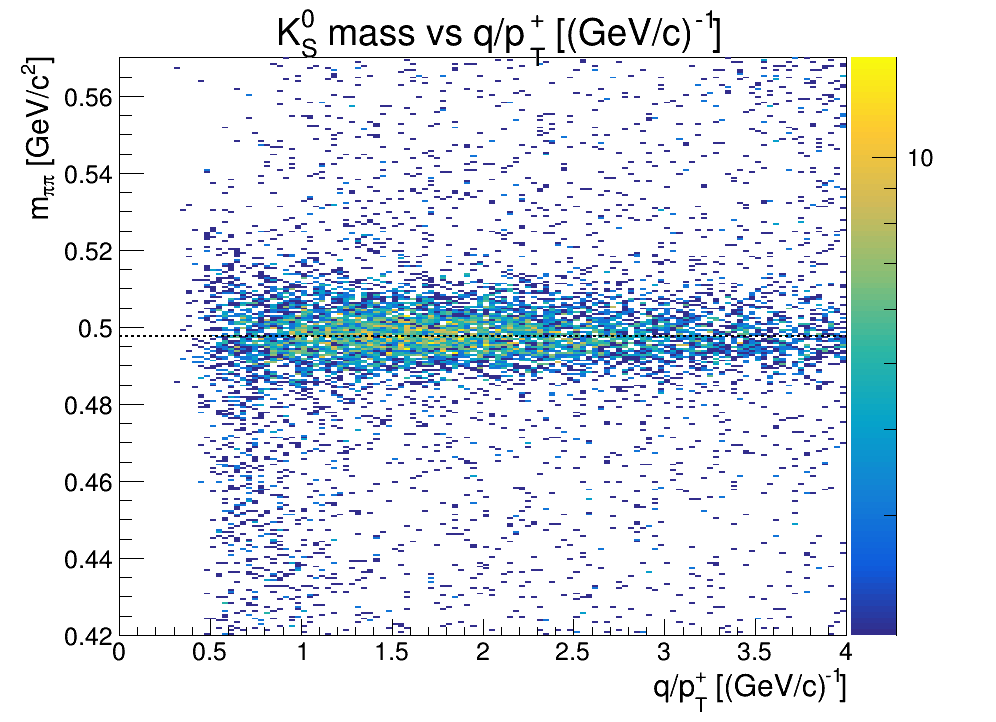

mass_vs_phase_space_exactCut1_unlike/h_mass_vs_qOverPt_negative


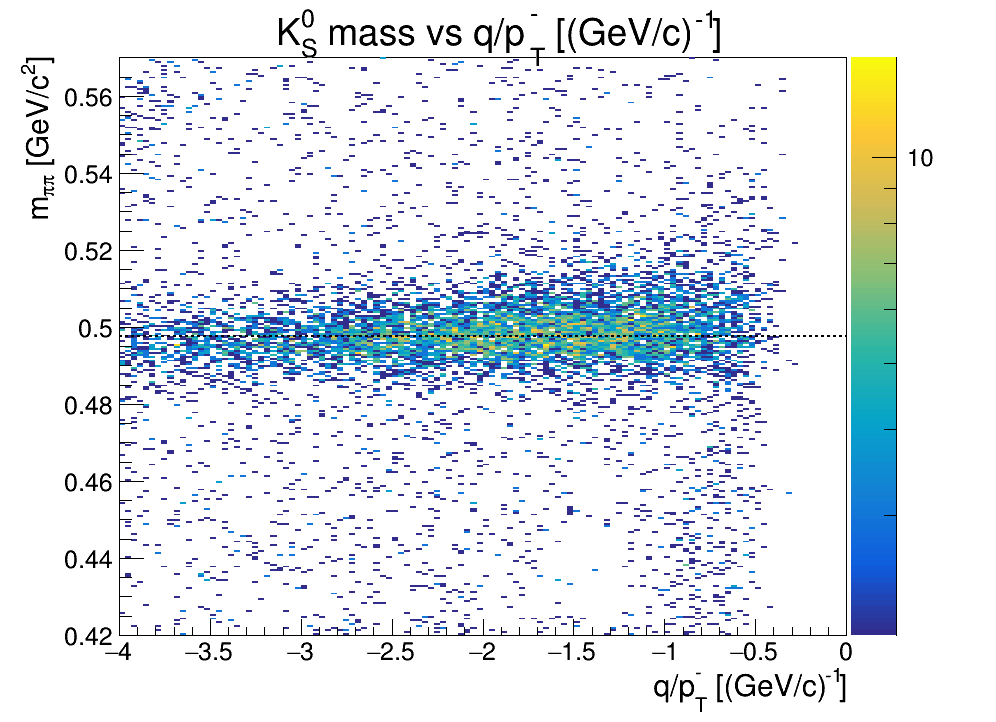

mass_vs_phase_space_exactCut1_unlike/h_delta_phi_vs_mass_vs_pt


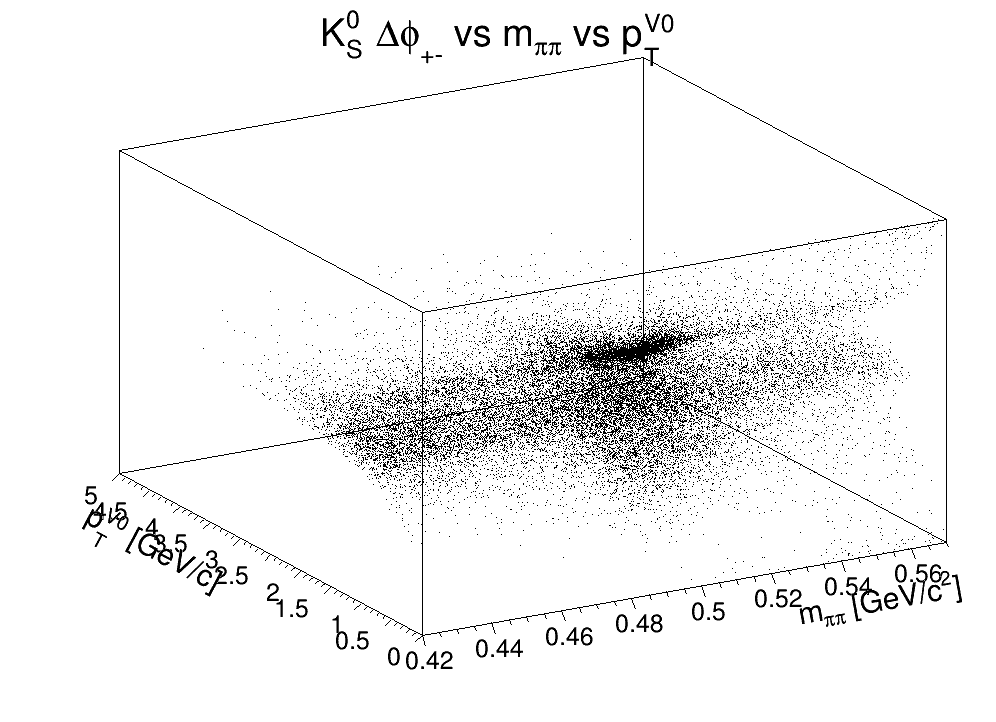

Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Error in <TGaxis::PaintAxis>: negative logarithmic axis
Error in <TGaxis::PaintAxis>: negative logarithmic axis
Error in <TGaxis::PaintAxis>: negative logarithmic axis
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_selected_plot.png has been created
Error in <TGaxis::PaintAxis>: ne

In [7]:
NAME_FILTERS = [
    "v0_phi",
    "phi_positive",
    "phi_negative",
    "delta_phi",
    "decay_phi",
    "qOverPt",
]

selected_histograms = [
    (path, hist)
    for path, hist in all_histograms
    if any(token in path for token in NAME_FILTERS)
]

print(f"Selected {len(selected_histograms)} histograms")

canvas_selected = ROOT.TCanvas(
    "c_k0s_selected", "Selected K0S QA", CANVAS_WIDTH, CANVAS_HEIGHT
)

for full_path, hist in selected_histograms:
    print(full_path)
    keep_alive = draw_histogram(canvas_selected, hist, full_path)
    show_canvas(canvas_selected, OUTPUT_DIRECTORY / "_selected_plot.png")

selected_temp = OUTPUT_DIRECTORY / "_selected_plot.png"
if selected_temp.exists():
    selected_temp.unlink()


## Compare low- and high-mass phase-space maps side by side

This cell searches for histograms with the same name in `low_mass_window` and `high_mass_window`, then draws their normalized shapes next to each other. Normalization helps reveal a localized phase-space population even when the two mass windows contain different total yields.


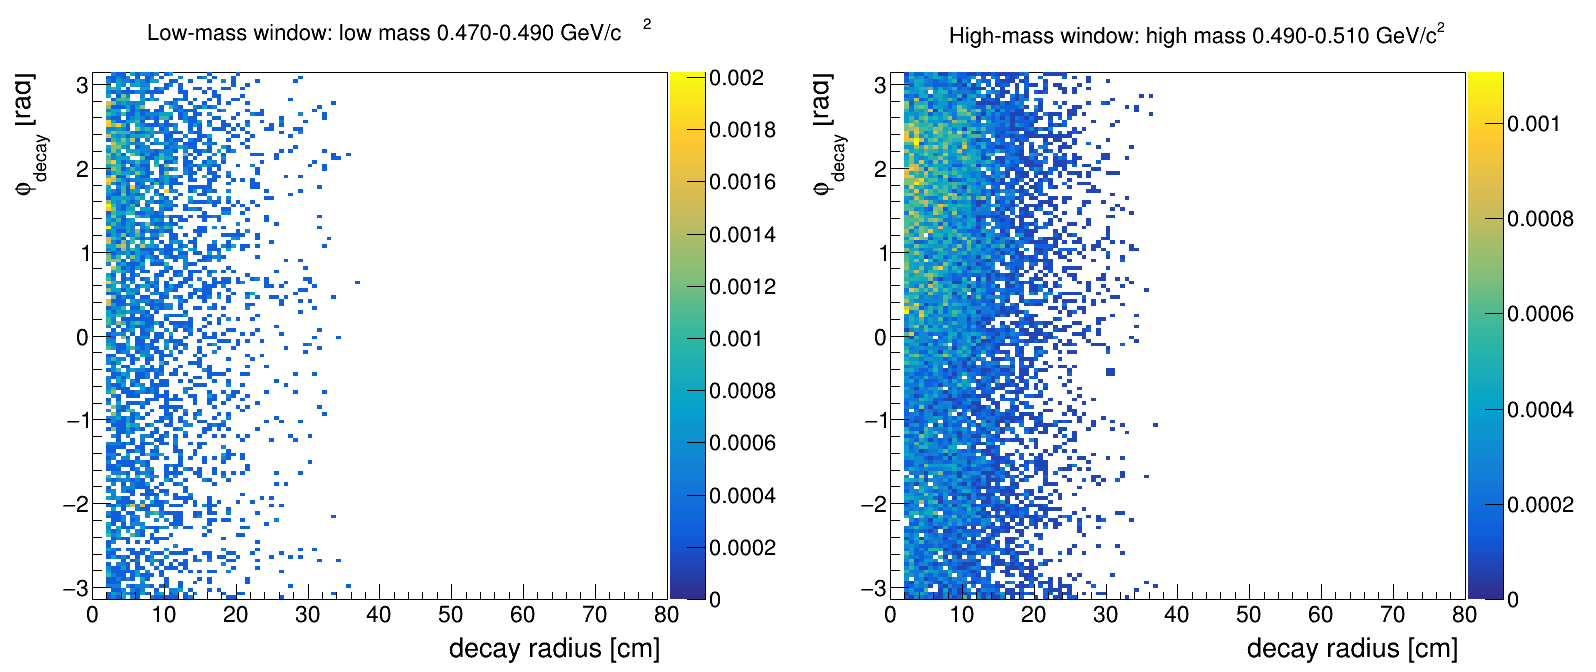

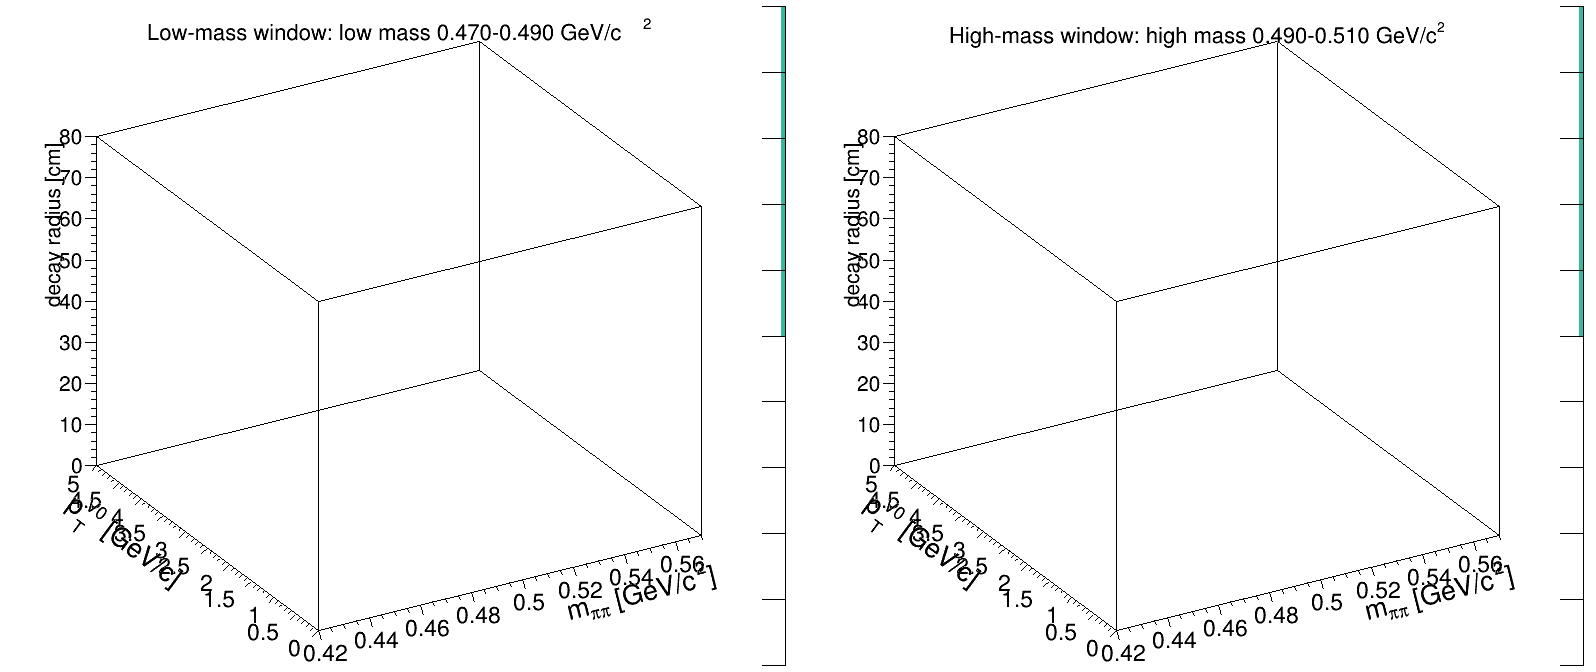

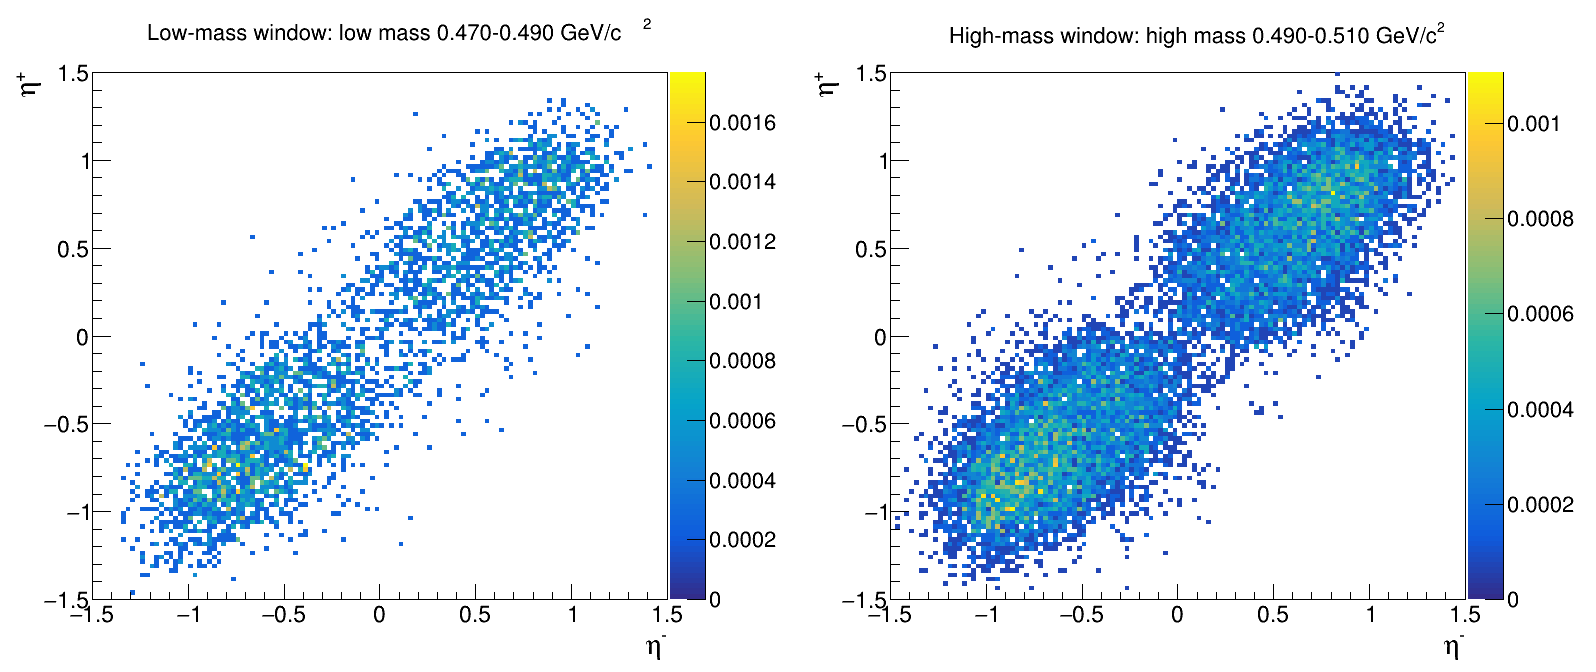

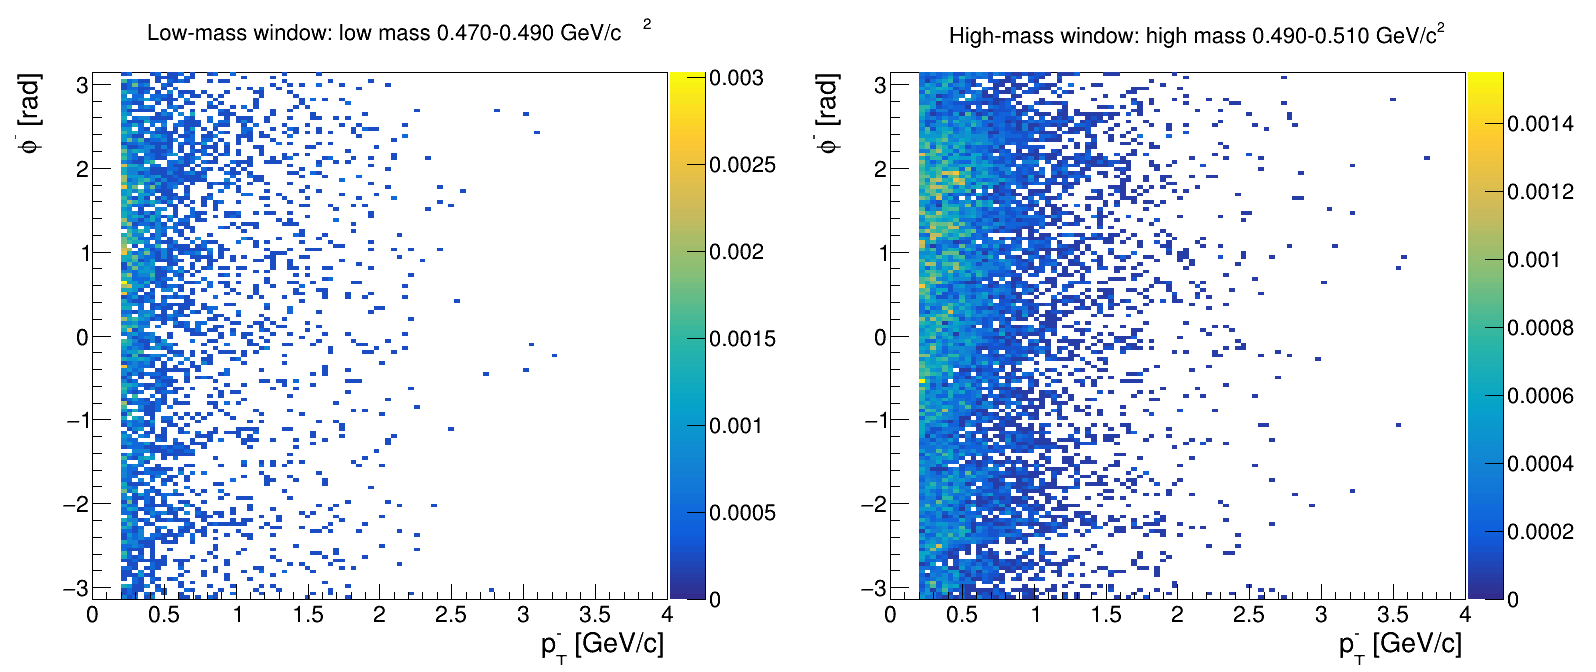

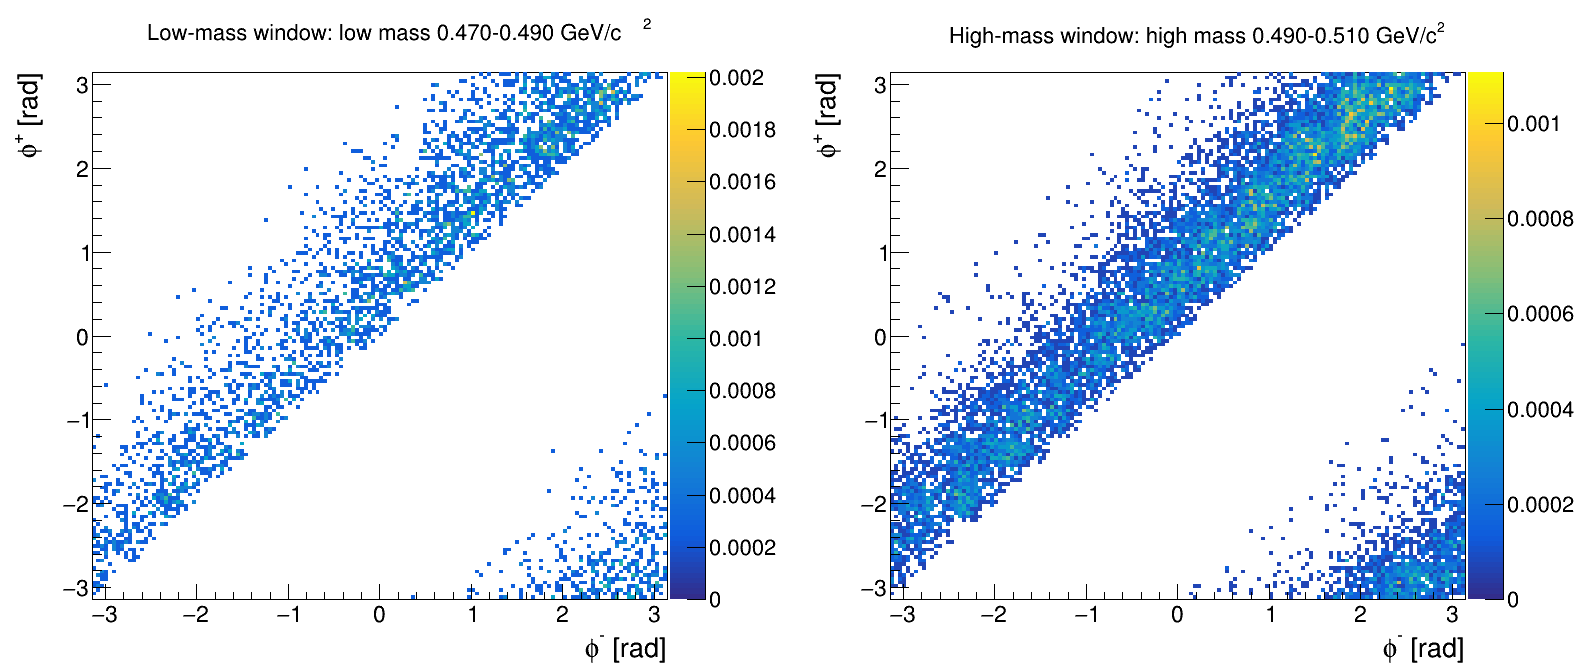

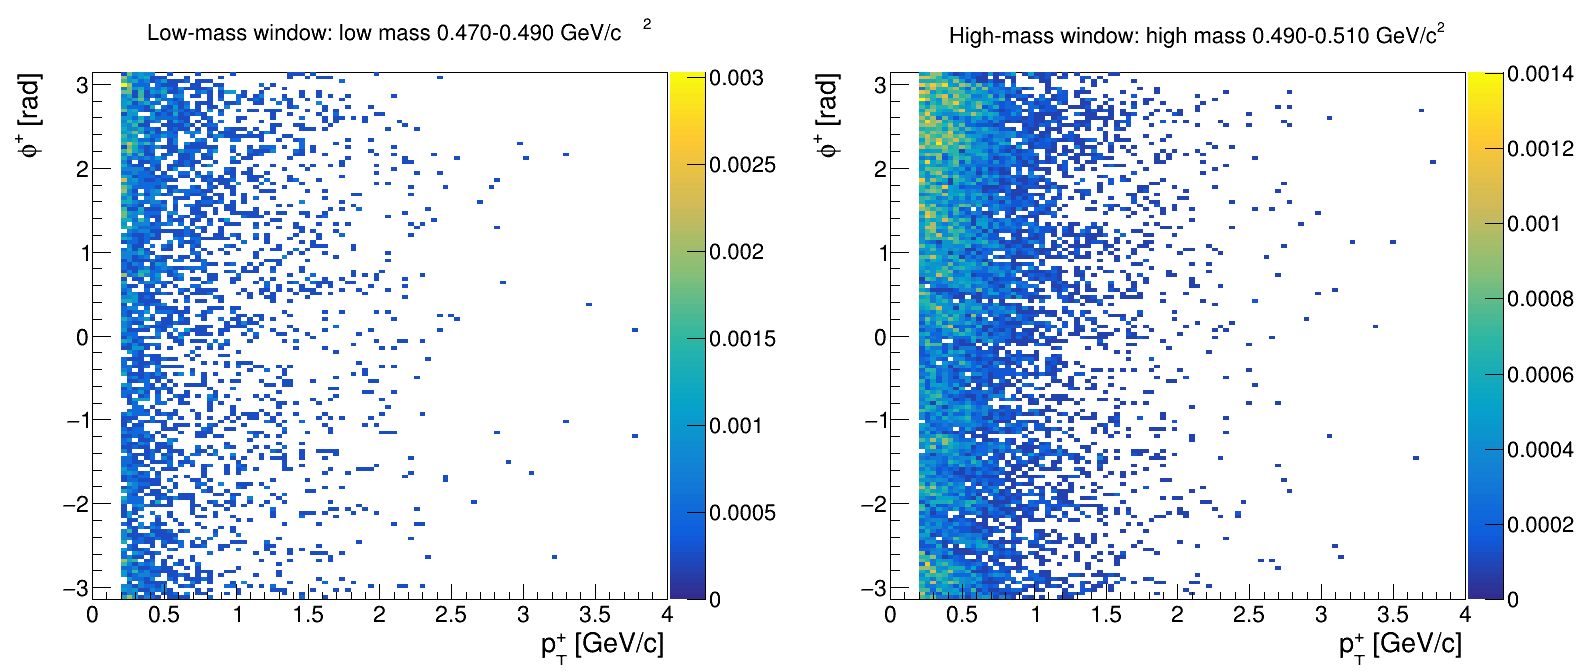

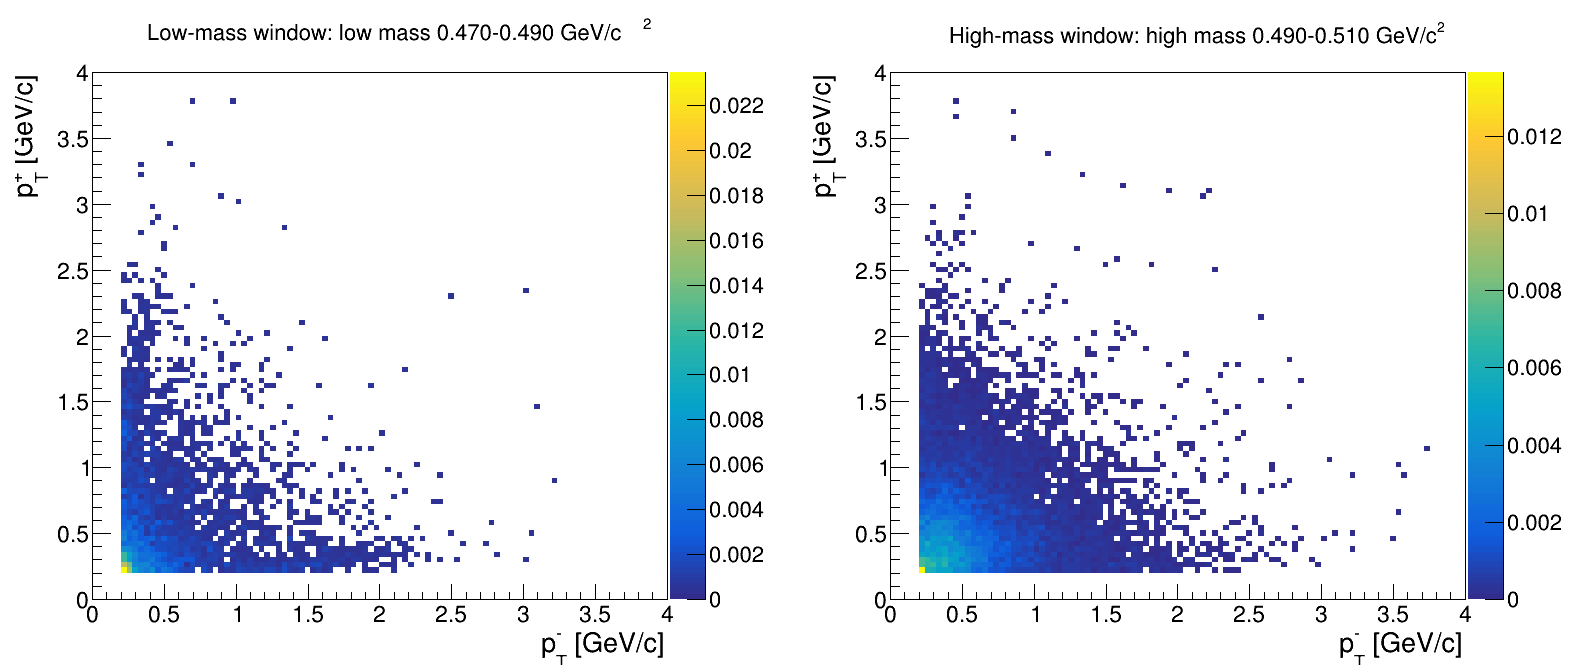

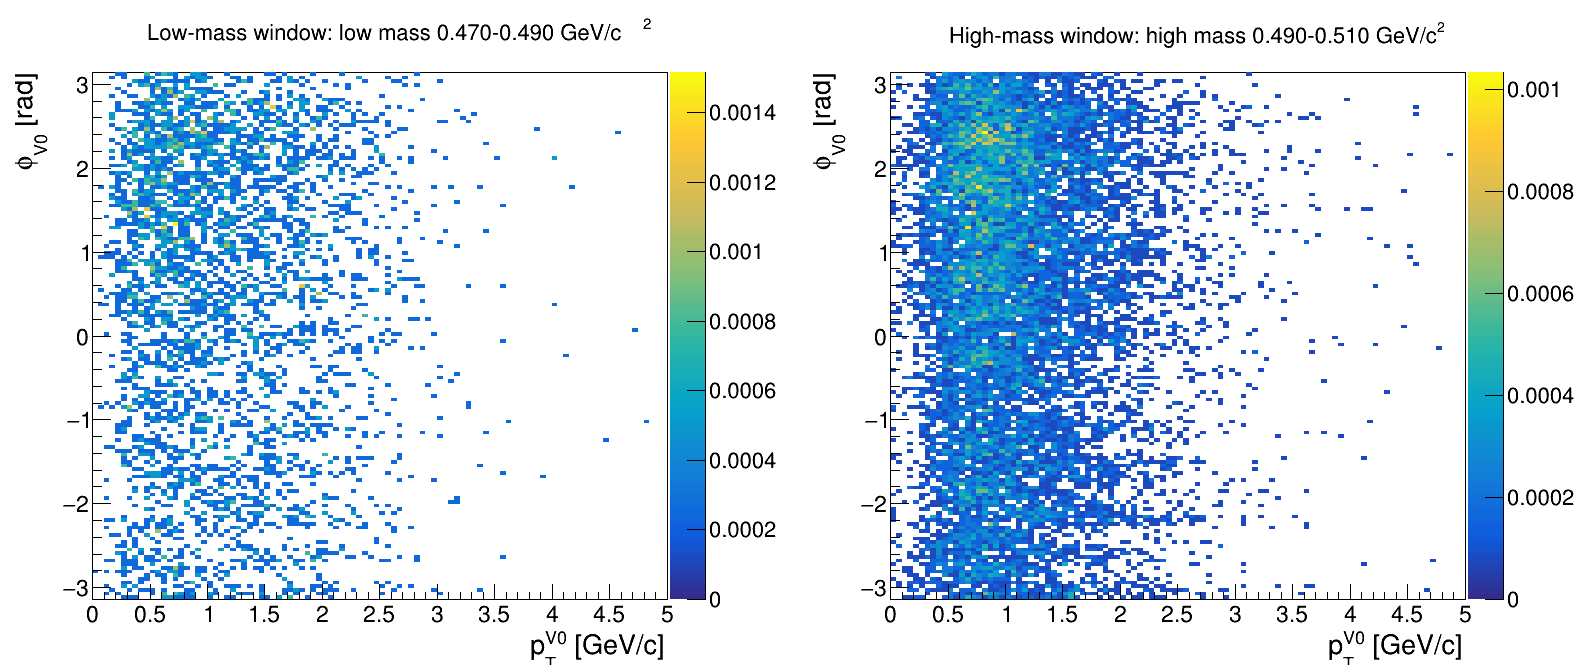

Wrote comparison PDF: /home/yoren/yumvd.Yandex.Disk/Yura/sPHENIX/tracking/drawings/output/k0s_double_peak_plots/k0s_low_high_window_comparison.pdf


Info in <TCanvas::Print>: pdf file output/k0s_double_peak_plots/k0s_low_high_window_comparison.pdf has been created
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_comparison.png has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/k0s_double_peak_plots/k0s_low_high_window_comparison.pdf
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_comparison.png has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/k0s_double_peak_plots/k0s_low_high_window_comparison.pdf
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_comparison.png has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/k0s_double_peak_plots/k0s_low_high_window_comparison.pdf
Info in <TCanvas::Print>: png file output/k0s_double_peak_plots/_comparison.png has been created
Info in <TCanvas::Print>: Current canvas added to pdf file output/k0s_double_peak_plots/k0s_low_high_window_comparison.pdf
Info

In [8]:
low_directory = root_file.GetDirectory("low_mass_window")
high_directory = root_file.GetDirectory("high_mass_window")

if low_directory and high_directory:
    low_maps = {
        path.split("/")[-1]: hist
        for path, hist in list_histograms(low_directory, "low_mass_window")
    }
    high_maps = {
        path.split("/")[-1]: hist
        for path, hist in list_histograms(high_directory, "high_mass_window")
    }

    common_names = sorted(set(low_maps) & set(high_maps))
    comparison_pdf = OUTPUT_DIRECTORY / "k0s_low_high_window_comparison.pdf"

    comparison_canvas = ROOT.TCanvas(
        "c_low_high", "Low/high mass comparison", 1600, 700
    )

    if SAVE_MULTIPAGE_PDF and common_names:
        comparison_canvas.Print(f"{comparison_pdf}[")

    for name in common_names:
        h_low = low_maps[name].Clone(f"{name}_low_normalized")
        h_high = high_maps[name].Clone(f"{name}_high_normalized")
        h_low.SetDirectory(0)
        h_high.SetDirectory(0)

        if h_low.Integral() > 0:
            h_low.Scale(1.0 / h_low.Integral())
        if h_high.Integral() > 0:
            h_high.Scale(1.0 / h_high.Integral())

        comparison_canvas.Clear()
        comparison_canvas.Divide(2, 1)

        comparison_canvas.cd(1)
        ROOT.gPad.SetRightMargin(0.15)
        ROOT.gPad.SetLogz(LOGZ_FOR_2D)
        h_low.SetTitle(f"Low-mass window: {h_low.GetTitle()}")
        configure_axes(h_low)
        h_low.Draw("COLZ")

        comparison_canvas.cd(2)
        ROOT.gPad.SetRightMargin(0.15)
        ROOT.gPad.SetLogz(LOGZ_FOR_2D)
        h_high.SetTitle(f"High-mass window: {h_high.GetTitle()}")
        configure_axes(h_high)
        h_high.Draw("COLZ")

        comparison_canvas.Update()
        comparison_canvas.SaveAs(str(OUTPUT_DIRECTORY / "_comparison.png"))
        display(Image(filename=str(OUTPUT_DIRECTORY / "_comparison.png")))

        if SAVE_MULTIPAGE_PDF:
            comparison_canvas.Print(str(comparison_pdf))

    if SAVE_MULTIPAGE_PDF and common_names:
        comparison_canvas.Print(f"{comparison_pdf}]")
        print(f"Wrote comparison PDF: {comparison_pdf.resolve()}")

    comparison_temp = OUTPUT_DIRECTORY / "_comparison.png"
    if comparison_temp.exists():
        comparison_temp.unlink()
else:
    print("The low_mass_window and/or high_mass_window directory is missing.")


In [9]:
# Close the ROOT file when finished.
root_file.Close()
print("ROOT file closed.")


ROOT file closed.
